# SISTECH 2026 — Final Project - MLOps Checkpoint 1

Notebook ini membangun dataset fitur dan label untuk aplikasi keselamatan pengguna transit,
memakai Chicago Crimes dan stasiun CTA sebagai analog struktural stasiun MRT.

**Alur yang akan dilalui:**
1. Setup & load dataset (Chicago Crimes)
2. Pembersihan data
3. **EDA** — memahami pola kejahatan lintas *waktu* dan *lokasi*
4. **Feature Engineering** — temporal (cyclical encoding) & spasial (grid aggregation)
5. **Pseudo-Labeling** — severity scoring + temporal decay + agregasi spasial → Risk Score
6. Menyusun & menyimpan dataset akhir (CSV/Parquet)

# 0. Installation & Setup

In [1]:
!pip install -q gdown pyarrow seaborn scikit-learn

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

DATA_DIR = Path("data")
DATA_DIR.mkdir(parents=True, exist_ok=True)
print(f"Folder data siap di: {DATA_DIR.resolve()}")

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 40)
print("Setup selesai ✅")

Folder data siap di: /content/data
Setup selesai ✅


# 1. Download & Import Dataset

## 1.1 Dataset Chicago Crimes

Memakai dataset **Chicago Crimes**. Kolom-kolom penting:
`Date`, `Primary Type`, `Description`, `Latitude`, `Longitude`, `Arrest`, `Location Description`.

In [3]:
import gdown

# Chicago Crimes
FILE_ID = "12K13Az7ynV3ZVimSARImgggnbDbVqjk_"
OUTPUT  = DATA_DIR / "chicago_crimes.csv"

gdown.download(id=FILE_ID, output=str(OUTPUT), quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=12K13Az7ynV3ZVimSARImgggnbDbVqjk_
From (redirected): https://drive.google.com/uc?id=12K13Az7ynV3ZVimSARImgggnbDbVqjk_&confirm=t&uuid=8cacdfca-684f-4905-a22f-9da00bf16e3e
To: /content/data/chicago_crimes.csv
100%|██████████| 2.37G/2.37G [00:30<00:00, 77.4MB/s]


'data/chicago_crimes.csv'

In [4]:
usecols = ["ID", "Date", "Primary Type", "Description",
           "Location Description", "Arrest", "Latitude", "Longitude", "Year"]

df = pd.read_csv(OUTPUT, usecols=lambda c: c in usecols)
print("Shape mentah:", df.shape)
df.head()

Shape mentah: (8534663, 9)


,ID,Date,Primary Type,Description,Location Description,Arrest,Year,Latitude,Longitude
0,14165870,04/11/2026 12:00:00 AM,THEFT,$500 AND UNDER,STREET,False,2026,41.801025,-87.652621
1,14170655,04/11/2026 12:00:00 AM,DECEPTIVE PRACTICE,FINANCIAL IDENTITY THEFT $300 AND UNDER,RESIDENCE,False,2026,NaN,NaN
2,14164088,04/11/2026 12:00:00 AM,BATTERY,SIMPLE,STREET,False,2026,41.884097,-87.675228
3,14163678,04/11/2026 12:00:00 AM,DECEPTIVE PRACTICE,THEFT OF LOST / MISLAID PROPERTY,APARTMENT,True,2026,41.977655,-87.697553
4,14164937,04/11/2026 12:00:00 AM,THEFT,THEFT FROM MOTOR VEHICLE,GAS STATION,False,2026,41.954538,-87.651148


In [5]:
n_years = 3

if "Year" in df.columns:
    last_year = int(df["Year"].max())
    df = df[df["Year"] >= last_year - (n_years - 1)].copy()
    print(f"Subset {last_year - (n_years - 1)}-{last_year}. Shape:", df.shape)

Subset 2024-2026. Shape: (553919, 9)


Subset yang digunakan:
**3 Tahun terakhir yang tersedia di dataset (2024 - 2026)**.

**Justifikasi:**

1. **Rentang tahun dipilih, bukan area / district**, supaya variasi spasial (hotspot vs area aman) tetap utuh untuk dianalisis. Krusial karena Risk Score sangat bergantung pada sinyal spasial yang kaya. Membatasi ke satu area/district justru menghilangkan variasi itu sebelum sempat dianalisis.

2.  **3 tahun** dipilih supaya pola musiman (`month`, `day-of-week`) tidak bias ke satu musim / periode tertentu, sekaligus menggunakan data paling terkini yang tersedia supaya relevan dengan kondisi kejahatan Chicago saat ini.

## 1.2 Dataset Stasiun CTA

Chicago tidak punya MRT, tapi punya sistem transit rel sejenis yaitu CTA 'L' (elevated train). Stasiun CTA dipakai sebagai analog struktural untuk area sekitar stasiun MRT, jadi selain Chicago Crimes, satu dataset lagi diimpor, yaitu data stasiun CTA dari City of Chicago Data Portal (resource id `8pix-ypme`).

Dataset ini dipakai belakangan di Section 2 untuk mempersempit scope spasial dari "seluruh kota" jadi radius jalan kaki 600 meter dari stasiun CTA terdekat.

Dataset ini bersifat snapshot kondisi terkini (bukan data historis per tahun seperti Chicago Crimes), karena satu baris merepresentasikan satu titik stop / entrance stasiun, bukan satu kejadian. Kolom yang diambil dibatasi ke `stop_id`, `station_name`, dan `location`, kolom lain seperti flag jalur (`red`, `blue`, `g`, dst) dan metadata region internal Socrata tidak relevan untuk kebutuhan jarak spasial.

In [6]:
import requests

CTA_URL = "https://data.cityofchicago.org/resource/8pix-ypme.json?$limit=5000"
resp = requests.get(CTA_URL)
resp.raise_for_status()

cta_cols_needed = ["stop_id", "station_name", "location"]
cta_raw = pd.DataFrame(resp.json())[cta_cols_needed]

print("Shape CTA raw (setelah trim kolom):", cta_raw.shape)
cta_raw.head()

Shape CTA raw (setelah trim kolom): (302, 3)


,stop_id,station_name,location
0,30162,18th,"{'latitude': '41.857908', 'longitude': '-87.66..."
1,30161,18th,"{'latitude': '41.857908', 'longitude': '-87.66..."
2,30022,35th/Archer,"{'latitude': '41.829353', 'longitude': '-87.68..."
3,30023,35th/Archer,"{'latitude': '41.829353', 'longitude': '-87.68..."
4,30213,35th-Bronzeville-IIT,"{'latitude': '41.831677', 'longitude': '-87.62..."


In [7]:
if "lat" in cta_raw.columns and "lon" in cta_raw.columns:
    cta_raw["cta_lat"] = cta_raw["lat"].astype(float)
    cta_raw["cta_lon"] = cta_raw["lon"].astype(float)
elif "location" in cta_raw.columns:
    cta_raw["cta_lat"] = cta_raw["location"].apply(lambda d: float(d["latitude"]))
    cta_raw["cta_lon"] = cta_raw["location"].apply(lambda d: float(d["longitude"]))
else:
    raise ValueError("Kolom koordinat CTA tidak ketemu, cek manual dari hasil print kolom di atas")

name_col = "station_name" if "station_name" in cta_raw.columns else "stop_name"

cta_stations = (cta_raw[[name_col, "cta_lat", "cta_lon"]]
                 .rename(columns={name_col: "station_name"})
                 .drop_duplicates(subset="station_name")
                 .dropna(subset=["cta_lat", "cta_lon"])
                 .reset_index(drop=True))

print(f"Jumlah stasiun CTA unik: {len(cta_stations)}")
cta_stations.head()

Jumlah stasiun CTA unik: 108


,station_name,cta_lat,cta_lon
0,18th,41.857908,-87.669147
1,35th/Archer,41.829353,-87.680622
2,35th-Bronzeville-IIT,41.831677,-87.625826
3,43rd,41.816462,-87.619021
4,47th,41.809209,-87.618826


# 2. Pembersihan Data

## 2.1 Audit Kualitas Data Mentah

Sebelum membuang baris apa pun, kondisi data mentah diperiksa lebih dulu. Tujuannya supaya
keputusan cleaning didasarkan pada bukti, bukan asumsi.

Tiga hal yang dicek:

1. **Missing value per kolom.** Perlu diketahui kolom mana yang bolong dan seberapa besar proporsinya, karena strategi penanganannya berbeda. Koordinat yang hilang membuat baris tidak bisa dipetakan ke grid spasial sama sekali, sehingga baris tersebut memang harus dibuang. Sebaliknya, kolom deskriptif yang bolong tidak selalu harus mematikan barisnya.
2. **Duplikasi.** Chicago Crimes adalah data operasional yang di-update berkala, sehingga satu `ID` bisa muncul lebih dari sekali ketika ada koreksi laporan. Duplikat semacam ini akan membuat satu insiden terhitung ganda dan menggelembungkan Risk Score di lokasi tersebut.
3. **Konsistensi tipe data.** Memastikan kolom numerik benar-benar terbaca sebagai numerik dan tidak jatuh menjadi object akibat karakter asing.


In [8]:
print("1. Missing value per kolom")
miss = pd.DataFrame({
    "n_missing": df.isna().sum(),
    "pct_missing": (df.isna().mean() * 100).round(3),
}).sort_values("n_missing", ascending=False)
print(miss.to_string())

print("\n2. Duplikasi")
dup_id   = df["ID"].duplicated().sum()
dup_full = df.duplicated(subset=["ID", "Date", "Primary Type", "Description"]).sum()
print(f"ID berulang          : {dup_id:,} ({dup_id / len(df) * 100:.3f}%)")
print(f"Baris duplikat penuh : {dup_full:,}")

if dup_id > 0:
    before_dedup = len(df)
    df = df.drop_duplicates(subset="ID", keep="last").copy()
    print(f"-> Dedup by ID: {before_dedup:,} menjadi {len(df):,} baris "
          f"({before_dedup - len(df):,} dibuang)")
else:
    print("-> Tidak ada dedup yang perlu dilakukan")

print("\n3. Tipe data")
print(df.dtypes.to_string())


1. Missing value per kolom
                      n_missing  pct_missing
Latitude                   3023        0.546
Longitude                  3023        0.546
Location Description       2531        0.457
ID                            0        0.000
Date                          0        0.000
Description                   0        0.000
Primary Type                  0        0.000
Year                          0        0.000
Arrest                        0        0.000

2. Duplikasi
ID berulang          : 0 (0.000%)
Baris duplikat penuh : 0
-> Tidak ada dedup yang perlu dilakukan

3. Tipe data
ID                        int64
Date                     object
Primary Type             object
Description              object
Location Description     object
Arrest                     bool
Year                      int64
Latitude                float64
Longitude               float64


## 2.2 Pembersihan data

- **Parse kolom `Date`** menjadi tipe datetime (format Chicago: `MM/DD/YYYY HH:MM:SS AM/PM`).
- **Buang baris tanpa koordinat / tanggal** — tanpa `Latitude`/`Longitude`, sebuah kejadian
  tidak bisa dipetakan ke grid spasial.
- **Filter koordinat di luar bounding box Chicago** (menyingkirkan koordinat rusak / 0,0).
- Turunkan kolom waktu dasar: `hour`, `dow` (day-of-week), `month`.

In [9]:
# Parse tanggal
df["Datetime"] = pd.to_datetime(df["Date"], format="%m/%d/%Y %I:%M:%S %p", errors="coerce")

before = len(df)
# Buang baris tanpa koordinat / tanpa tanggal valid
df = df.dropna(subset=["Latitude", "Longitude", "Datetime"]).copy()

# Bounding box kasar wilayah Chicago -> singkirkan koordinat rusak
df = df[df["Latitude"].between(41.60, 42.05) &
        df["Longitude"].between(-87.95, -87.50)].copy()

# Fitur waktu dasar
df["hour"]  = df["Datetime"].dt.hour
df["dow"]   = df["Datetime"].dt.dayofweek        # 0 = Senin ... 6 = Minggu
df["month"] = df["Datetime"].dt.month

print(f"Dibuang {before - len(df):,} baris. Shape bersih: {df.shape}")
df[["Datetime", "Primary Type", "Description", "Latitude", "Longitude", "hour", "dow"]].head()

Dibuang 3,023 baris. Shape bersih: (550896, 13)


,Datetime,Primary Type,Description,Latitude,Longitude,hour,dow
0,2026-04-11,THEFT,$500 AND UNDER,41.801025,-87.652621,0,5
2,2026-04-11,BATTERY,SIMPLE,41.884097,-87.675228,0,5
3,2026-04-11,DECEPTIVE PRACTICE,THEFT OF LOST / MISLAID PROPERTY,41.977655,-87.697553,0,5
4,2026-04-11,THEFT,THEFT FROM MOTOR VEHICLE,41.954538,-87.651148,0,5
5,2026-04-11,BATTERY,SIMPLE,41.951894,-87.747276,0,5


## 2.3 Membangun Subset Spasial: Radius Stasiun CTA

Menggunakan `cta_stations`, scope data dipersempit jadi radius jalan kaki 600 meter dari stasiun CTA terdekat.

Jarak dihitung pakai great circle distance (haversine), bukan jarak jaringan jalan sebenarnya, karena data jaringan pejalan kaki Chicago tidak tersedia. Untuk radius sekecil 600 meter, pendekatan ini cukup wajar, tapi tetap dicatat sebagai limitasi.

In [10]:
from sklearn.neighbors import BallTree

EARTH_RADIUS_M = 6_371_000

station_rad = np.radians(cta_stations[["cta_lat", "cta_lon"]].values)
station_tree = BallTree(station_rad, metric="haversine")

crime_rad = np.radians(df[["Latitude", "Longitude"]].values)
dist_rad, idx = station_tree.query(crime_rad, k=1)

df["dist_to_nearest_station_m"] = dist_rad[:, 0] * EARTH_RADIUS_M
df["nearest_station"] = cta_stations.loc[idx[:, 0], "station_name"].values

RADIUS_M = 600
before = len(df)
df = df[df["dist_to_nearest_station_m"] <= RADIUS_M].copy()

print(f"Subset radius {RADIUS_M}m dari stasiun CTA terdekat: {before:,} -> {len(df):,} baris "
      f"({len(df)/before*100:.1f}% dari data pasca-cleaning)")
df["dist_to_nearest_station_m"].describe()

Subset radius 600m dari stasiun CTA terdekat: 550,896 -> 152,769 baris (27.7% dari data pasca-cleaning)


,dist_to_nearest_station_m
count,152769.000000
mean,316.427923
std,160.038940
min,1.070747
25%,179.774231
50%,318.012081
75%,447.538654
max,599.993302


**Interpretasi hasil:**

Tiga hal yang perlu dibaca dari output di atas:

1. **Seberapa besar penyusutan data.** Persentase baris yang tersisa menunjukkan porsi kejahatan Chicago yang benar-benar terjadi di area jalan kaki sekitar stasiun. Ini sekaligus menegaskan bahwa scope analisis sudah benar-benar berpindah dari skala kota ke skala area stasiun.

2. **Sebaran jarak ke stasiun terdekat.** Kuartil yang terdistribusi cukup merata antara batas bawah dan batas radius menandakan tidak ada bias sistematis. Kalau kejadian menumpuk hanya tepat di depan stasiun, atau justru hanya di tepi radius, sinyal spasialnya akan timpang.

3. **Konsistensi dengan radius safe place.** Radius subset dipakai 600 meter, sedangkan radius penghitungan safe place dipakai 500 meter dan diukur dari centroid sel, bukan dari stasiun. Perbedaan ini disengaja: 600 meter menentukan area studi, sedangkan 500 meter merepresentasikan jarak jalan kaki cepat untuk mencari bantuan dari titik pengguna berada.

**Limitasi.** Jarak dihitung dengan great circle distance (haversine), bukan jarak jaringan jalan
sebenarnya, karena data jaringan pejalan kaki Chicago tidak tersedia. Untuk radius ratusan meter
pendekatan ini wajar, namun jarak tempuh sesungguhnya akan lebih panjang, terutama pada blok yang
terpotong rel, sungai, atau jalan besar.


# 3. Exploratory Data Analysis (EDA)

Membangun **intuisi** tentang **kapan** dan **di mana** kejahatan
paling sering terjadi. Intuisi inilah yang nanti memandu keputusan feature engineering dan pseudo-labeling.

## 3.1 Jenis Kejahatan Paling Umum

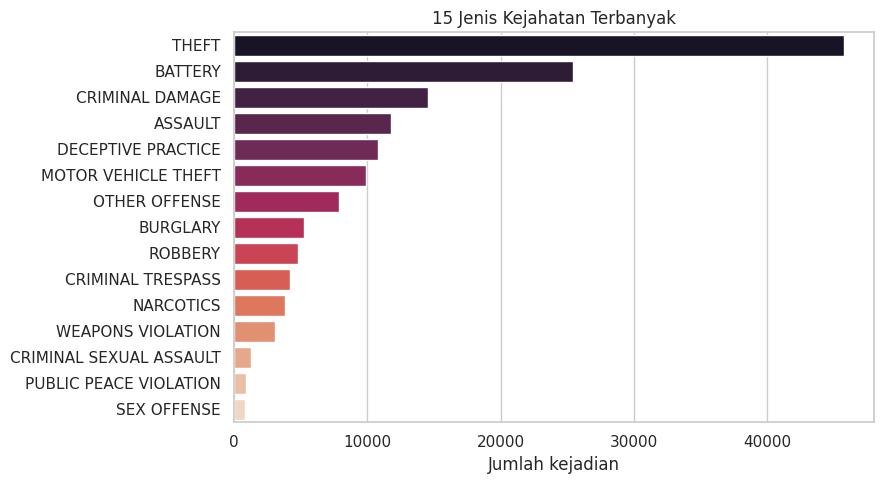

In [11]:
top_types = df["Primary Type"].value_counts().head(15)

plt.figure(figsize=(9, 5))
sns.barplot(x=top_types.values, y=top_types.index, hue=top_types.index,
            palette="rocket", legend=False)
plt.title("15 Jenis Kejahatan Terbanyak")
plt.xlabel("Jumlah kejadian"); plt.ylabel("")
plt.tight_layout(); plt.show()

## 3.2 Pola Temporal: Jam, Hari, Bulan

Pola inilah yang membuat fitur
temporal menjadi penting.

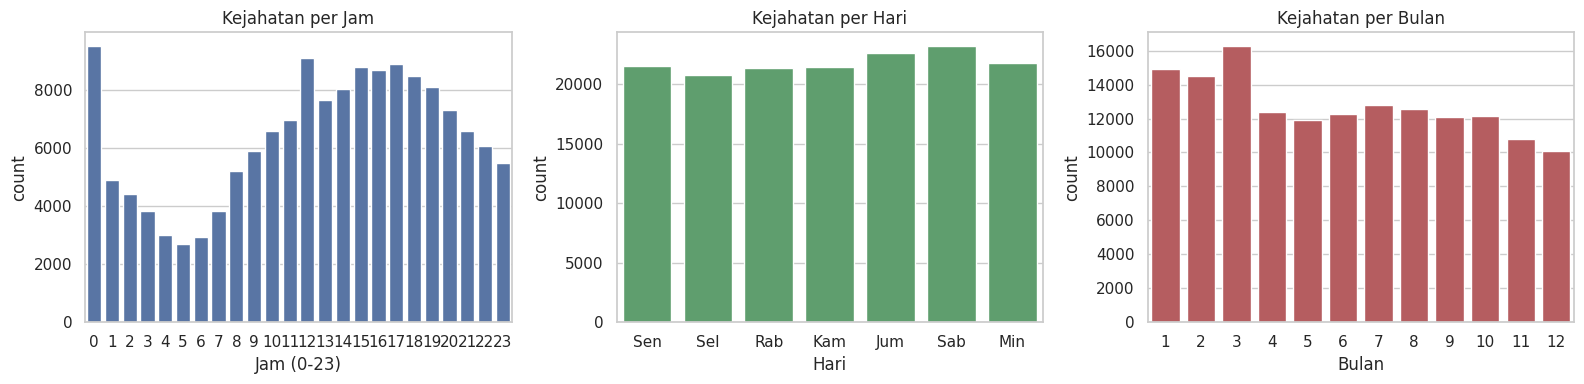

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Per jam
sns.countplot(x="hour", data=df, ax=axes[0], color="#4C72B0")
axes[0].set_title("Kejahatan per Jam"); axes[0].set_xlabel("Jam (0-23)")

# Per hari dalam seminggu
labels_dow = ["Sen","Sel","Rab","Kam","Jum","Sab","Min"]
sns.countplot(x="dow", data=df, order=[0,1,2,3,4,5,6], ax=axes[1], color="#55A868")
axes[1].set_title("Kejahatan per Hari"); axes[1].set_xlabel("Hari")
axes[1].set_xticks(range(7)); axes[1].set_xticklabels(labels_dow)

# Per bulan
sns.countplot(x="month", data=df, ax=axes[2], color="#C44E52")
axes[2].set_title("Kejahatan per Bulan"); axes[2].set_xlabel("Bulan")

plt.tight_layout(); plt.show()

## 3.3 Pola Spasial: Hotspot

Sebaran koordinat memperlihatkan **konsentrasi** kejahatan. `hexbin` cocok untuk
menunjukkan kepadatan tanpa terganggu jutaan titik yang saling menimpa.

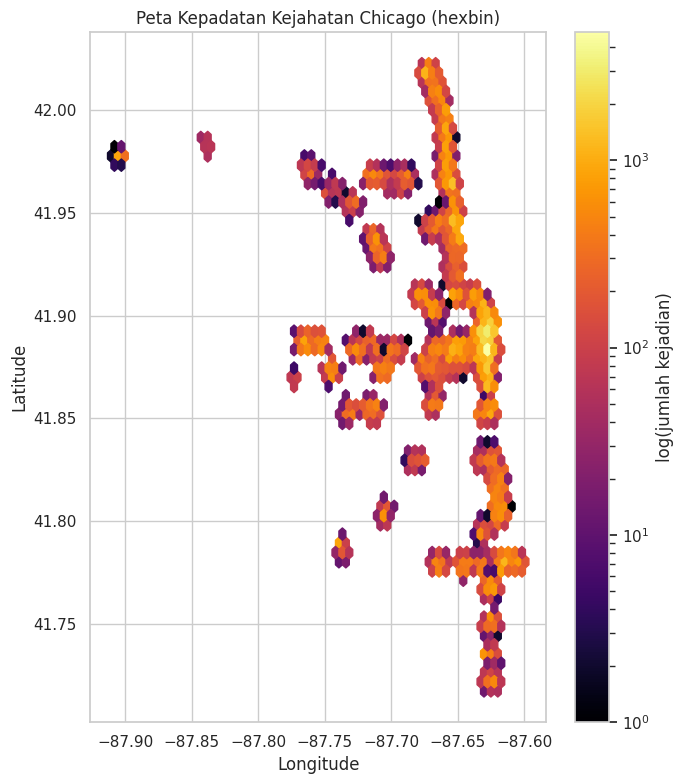

In [13]:
plt.figure(figsize=(7, 8))
hb = plt.hexbin(df["Longitude"], df["Latitude"], gridsize=60,
                cmap="inferno", mincnt=1, bins="log")
plt.colorbar(hb, label="log(jumlah kejadian)")
plt.title("Peta Kepadatan Kejahatan Chicago (hexbin)")
plt.xlabel("Longitude"); plt.ylabel("Latitude")
plt.tight_layout(); plt.show()

## 3.4 Pola Jam: Akhir Pekan vs Hari Kerja

Di sini saya pisahkan **hari kerja** vs **akhir pekan** untuk melihat apakah jam sibuk kejahatannya bergeser tergantung dengan jenis harinya.

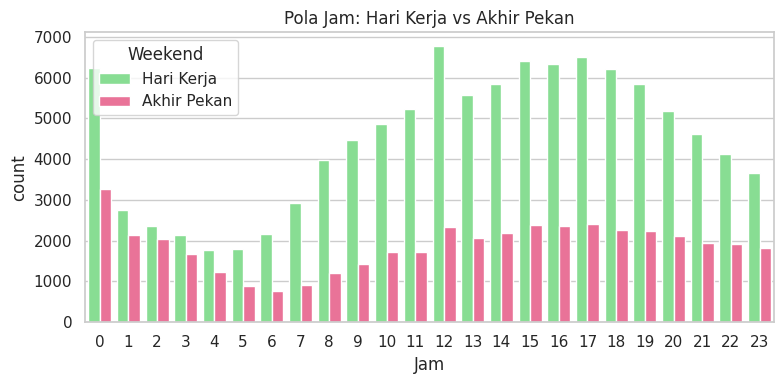

In [14]:
df["is_weekend"] = df["dow"].isin([5, 6])

plt.figure(figsize=(8, 4))
sns.countplot(x="hour", hue="is_weekend", data=df, palette=["#7AEB89", "#FC6091"])
plt.title("Pola Jam: Hari Kerja vs Akhir Pekan")
plt.xlabel("Jam"); plt.legend(title="Weekend", labels=["Hari Kerja", "Akhir Pekan"])
plt.tight_layout(); plt.show()

## 3.5 Pola Waktu: Per Jenis Kejahatan

Membandingkan distribusi jam untuk 5 jenis kejahatan terbanyak, untuk melihat apakah pola waktu ini cukup berbeda.

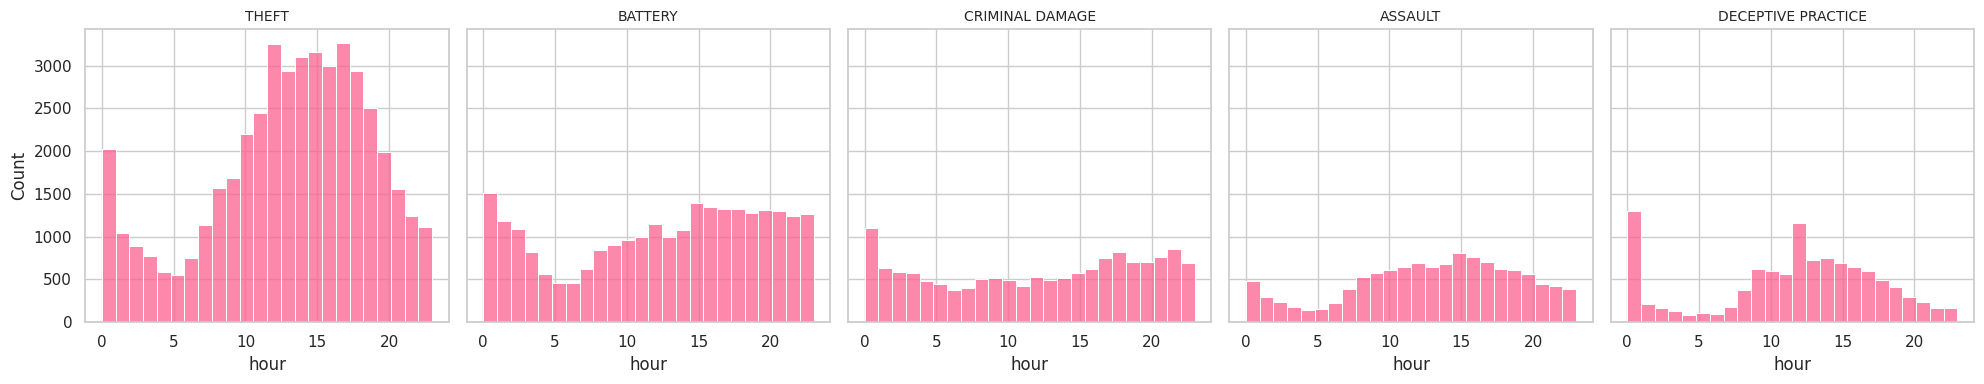

In [15]:
top5_types = df["Primary Type"].value_counts().head(5).index

fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharey=True)
for ax, crime in zip(axes, top5_types):
    sns.histplot(df[df["Primary Type"] == crime]["hour"], bins=24, ax=ax, color="#FC6091")
    ax.set_title(crime, fontsize=10)
plt.tight_layout(); plt.show()

## 3.6 Pola Interaksi Hari x Jam

Heatmap di bawah menunjukkan jumlah kejadian untuk tiap kombinasi hari x jam.

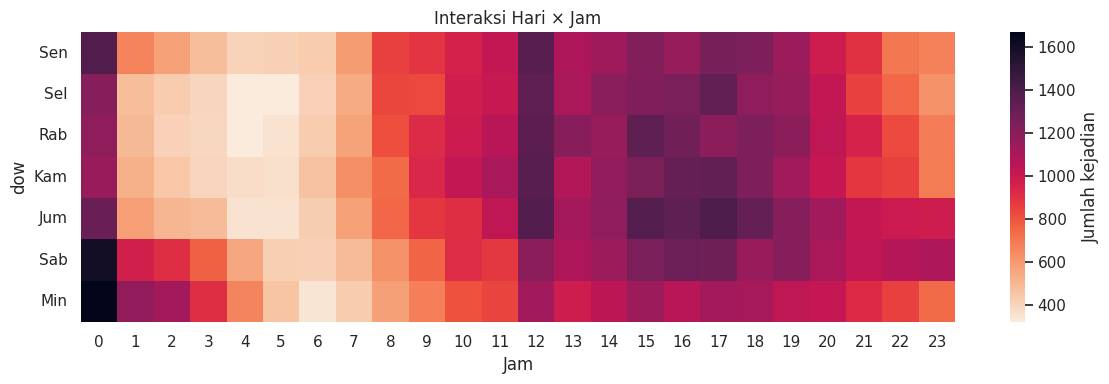

In [16]:
pivot = df.pivot_table(index="dow", columns="hour", values="ID", aggfunc="count")

plt.figure(figsize=(12, 4))
sns.heatmap(pivot, cmap="rocket_r", cbar_kws={"label": "Jumlah kejadian"})
plt.yticks(np.arange(7) + 0.5, ["Sen","Sel","Rab","Kam","Jum","Sab","Min"], rotation=0)
plt.title("Interaksi Hari × Jam")
plt.xlabel("Jam"); plt.tight_layout(); plt.show()

### Verifikasi Dugaan Artefak Pencatatan Waktu

Lonjakan tajam di jam 0 dan jam 12 pada grafik-grafik sebelumnya **mencurigakan** karena jika waktu kejadian benar-benar natural, seharusnya tidak ada satu jam yang jauh lebih tinggi dibanding jam-jam di sekitarnya secara konsisten.

Dugaan: ini adalah **artefak pencatatan**. saat waktu kejadian tidak diketahui pasti oleh petugas /  pelapor, sistem kemungkinan mencatat waktu yang dibulatkan ke jam penuh (`00:00` atau `12:00`) sebagai default, bukan waktu kejadian yang sesungguhnya.

Untuk membuktikan ini, saya coba untuk cek distribusi menit pada baris-baris yang jamnya tepat 0 dan 12. Jika waktu kejadian benar-benar presisi / acak, distribusi menit (0-59) seharusnya tersebar relatif merata. Jika sebaliknya menit `:00` muncul jauh lebih sering daripada menit lain, artinya itu bukti kuat bahwa waktu-waktu tersebut memang dibulatkan, bukan dicatat secara presisi.

In [17]:
print(df[df["hour"] == 0]["Datetime"].dt.minute.value_counts().head())
print(df[df["hour"] == 12]["Datetime"].dt.minute.value_counts().head())

Datetime
0     4941
1      892
30     683
15     228
45     159
Name: count, dtype: int64
Datetime
0     3125
30     991
45     356
15     350
20     257
Name: count, dtype: int64


Hasil ini mengonfirmasi dugaan saya yaitu menit `:00` muncul jauh lebih dominan dibanding menit lain yang tersebar relatif merata (ratusan hingga sekitar seribu kejadian per menit). Jika waktu kejadian benar-benar presisi dan acak, seharusnya tidak ada satu menit tertentu yang menonjol setajam ini, apalagi persis di menit bulat (`:00`).

**Kesimpulan:** baris-baris dengan `hour == 0` atau `hour == 12` dan menit persis `:00`
kemungkinan besar adalah kejadian yang **waktu sebenarnya tidak diketahui**, lalu dicatat dengan waktu default /dibulatkan. Ini perlu ditangani sebelum lanjut ke feature engineering & pseudo-labeling, karena jika dibiarkan, Risk Score bisa salah menganggap jam 0 dan 12 sebagai jam yang jauh lebih berisiko.

## 3.7 Dampak Artefak Pencatatan Waktu terhadap Pola Jam

Setelah dikonfirmasi bahwa waktu `:00` di jam 0 dan 12 kemungkinan besar adalah artefak, perlu tahu seberapa besar dampaknya terhadap keseluruhan pola jam.

Apakah cukup
signifikan untuk mengubah kesimpulan EDA, atau cuma sedikit dan bisa diabaikan.

Baris difilter dengan flag `time_likely_imprecise` (jam 0 atau 12, dengan menit dan detik persis 0 supaya tidak salah membuang kejadian yang memang betul terjadi tepat
di jam tersebut dengan presisi menit / detik lain). Lalu saya bandingkan pola jam sebelum vs sesudah baris ini dikeluarkan.

Baris dengan waktu kemungkinan tidak presisi: 5.28%


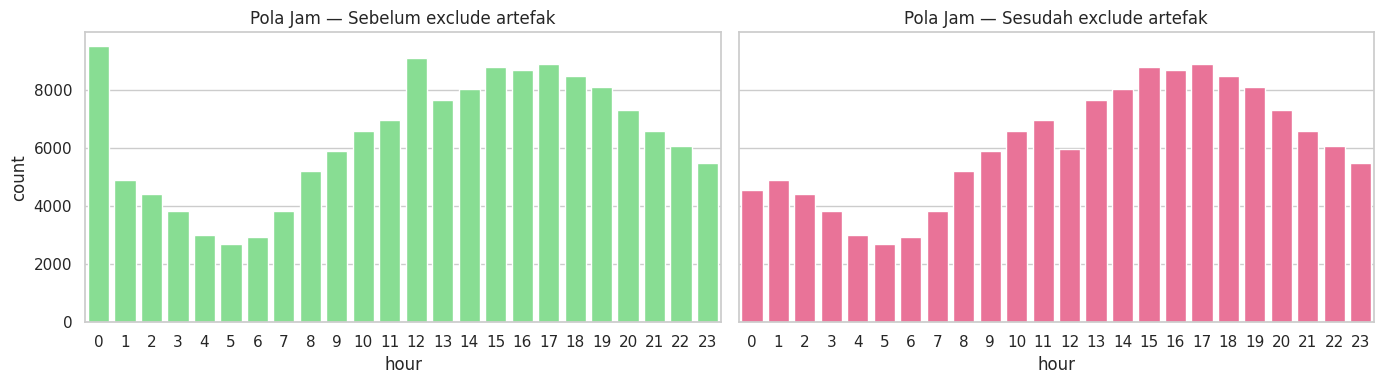

In [18]:
# Flag baris yang kemungkinan waktu-nya "dibulatkan" (menit=0 & detik=0)
df["time_likely_imprecise"] = (
    (df["Datetime"].dt.minute == 0) & (df["Datetime"].dt.second == 0) &
    (df["hour"].isin([0, 12]))
)
pct_imprecise = df["time_likely_imprecise"].mean() * 100
print(f"Baris dengan waktu kemungkinan tidak presisi: {pct_imprecise:.2f}%")

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
sns.countplot(x="hour", data=df, ax=axes[0], color="#7AEB89")
axes[0].set_title("Pola Jam — Sebelum exclude artefak")

df_clean_time = df[~df["time_likely_imprecise"]]
sns.countplot(x="hour", data=df_clean_time, ax=axes[1], color="#FC6091")
axes[1].set_title("Pola Jam — Sesudah exclude artefak")
plt.tight_layout(); plt.show()

**Interpretasi hasil:**

Persentase baris yang teridentifikasi berwaktu tidak presisi dapat dibaca dari output di atas.

- **Sebelum exclude:** jam 0 melonjak jauh di atas jam-jam di sekitarnya, padahal jam 23 dan jam 1
  seharusnya berada pada tingkat yang mirip. Jam 12 juga menonjol tidak wajar di tengah tren yang
  seharusnya naik landai menuju sore.
- **Sesudah exclude:** kedua lonjakan hilang dan kurva jam kembali mengikuti bentuk yang mulus.

Dampaknya cukup signifikan untuk mengubah kesimpulan EDA jika dibiarkan, karena jam 0 dan jam 12
akan salah dianggap sebagai jam paling rawan. Karena itu baris-baris tersebut dikeluarkan dari
seluruh analisis selanjutnya, agar Risk Score merefleksikan pola waktu kejadian yang sesungguhnya
dan bukan kebiasaan pencatatan petugas.


In [19]:
df = df_clean_time.copy()  # Gunakan vers yang sudah dibersihkan dari artefak

# 4. Feature Engineering

Kita akan membangun dua kelompok fitur:
- **Temporal** — merepresentasikan sifat **siklikal** waktu.
- **Spasial** — mengagregasi lokasi kontinu menjadi **grid** yang bisa dibandingkan.

## 4.1 Fitur Temporal: Cyclical Encoding

Waktu bersifat **siklikal**: jam `23:00` sebenarnya *berdekatan* dengan `00:00`, tetapi
jika kita pakai angka mentah (`23` vs `0`) model akan menganggapnya **berjauhan**
(selisih 23!). Solusi umum: petakan setiap nilai siklikal ke **lingkaran** dengan `sin` & `cos`:

$$x_{\sin} = \sin\!\left(\frac{2\pi \cdot v}{P}\right), \qquad x_{\cos} = \cos\!\left(\frac{2\pi \cdot v}{P}\right)$$

dengan $P$ = panjang siklus (24 untuk jam, 7 untuk hari, 12 untuk bulan).


In [20]:
def cyclical_encode(values, period):
    # Ubah nilai siklikal menjadi pasangan (sin, cos)
    radians = 2 * np.pi * values / period
    return np.sin(radians), np.cos(radians)

df["hour_sin"], df["hour_cos"] = cyclical_encode(df["hour"], 24)
df["dow_sin"],  df["dow_cos"]  = cyclical_encode(df["dow"],  7)

df[["hour", "hour_sin", "hour_cos", "dow", "dow_sin", "dow_cos"]].head()

,hour,hour_sin,hour_cos,dow,dow_sin,dow_cos
12,23,-0.258819,0.965926,4,-0.433884,-0.900969
18,23,-0.258819,0.965926,4,-0.433884,-0.900969
21,23,-0.258819,0.965926,4,-0.433884,-0.900969
26,23,-0.258819,0.965926,4,-0.433884,-0.900969
32,22,-0.500000,0.866025,4,-0.433884,-0.900969


**Bukti bahwa encoding ini benar.** Kita cek jarak antar-jam pada bidang (sin, cos):
`23:00` seharusnya lebih dekat ke `00:00` daripada ke `12:00`.

Jarak 23:00 -> 00:00 = 0.261  (harusnya KECIL)
Jarak 00:00 -> 12:00 = 2.000  (harusnya BESAR)


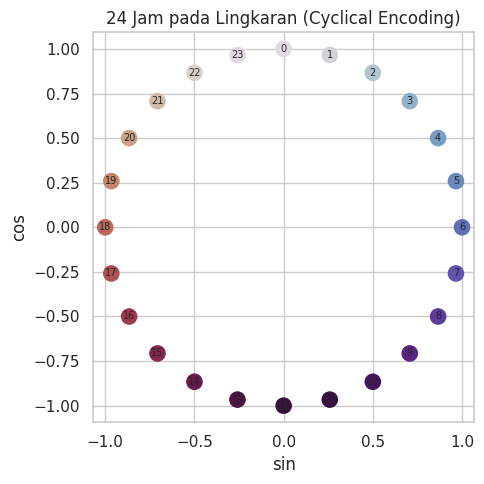

In [21]:
def point(v, p): return np.array(cyclical_encode(np.array([v]), p)).ravel()

d_23_to_0 = np.linalg.norm(point(23, 24) - point(0, 24))
d_0_to_12 = np.linalg.norm(point(0, 24)  - point(12, 24))
print(f"Jarak 23:00 -> 00:00 = {d_23_to_0:.3f}  (harusnya KECIL)")
print(f"Jarak 00:00 -> 12:00 = {d_0_to_12:.3f}  (harusnya BESAR)")

# Visualisasi 24 jam sebagai lingkaran
hs, hc = cyclical_encode(np.arange(24), 24)
plt.figure(figsize=(5,5))
plt.scatter(hs, hc, c=np.arange(24), cmap="twilight", s=120)
for h in range(24):
    plt.annotate(str(h), (hs[h], hc[h]), ha="center", va="center", fontsize=7)
plt.title("24 Jam pada Lingkaran (Cyclical Encoding)")
plt.xlabel("sin"); plt.ylabel("cos"); plt.axis("equal")
plt.tight_layout(); plt.show()

## 4.2 Fitur Spasial: Grid Aggregation

Koordinat lintang/bujur bersifat **kontinu & presisi tinggi**  dua titik yang selisihnya
sangat kecil praktis berada di lingkungan yang sama. Agar lokasi bisa **diagregasi dan
dibandingkan**, cara paling sederhana adalah **membulatkan koordinat** ke beberapa desimal,
sehingga titik-titik yang berdekatan jatuh ke *sel* yang sama.


In [22]:
ROUND_DECIMALS = 3

df["lat_r"] = df["Latitude"].round(ROUND_DECIMALS)
df["lon_r"] = df["Longitude"].round(ROUND_DECIMALS)
df["cell_id"] = df["lat_r"].astype(str) + "_" + df["lon_r"].astype(str)

print(f"Jumlah sel unik: {df['cell_id'].nunique():,}")
df[["Latitude", "Longitude", "lat_r", "lon_r", "cell_id"]].head()

Jumlah sel unik: 6,485


,Latitude,Longitude,lat_r,lon_r,cell_id
12,41.776093,-87.615523,41.776,-87.616,41.776_-87.616
18,41.858145,-87.712746,41.858,-87.713,41.858_-87.713
21,41.857535,-87.666137,41.858,-87.666,41.858_-87.666
26,41.874128,-87.628688,41.874,-87.629,41.874_-87.629
32,41.953100,-87.652079,41.953,-87.652,41.953_-87.652


### Keputusan Feature Engineering

**1. Ukuran sel.**

Diuji 2 versus 3 desimal secara kuantitatif (lihat 4.2b di bawah). Dipilih **3 desimal**, yang
setara sekitar 110 meter per sel, meskipun lebih sparse. Alasannya, resolusi 2 desimal setara
sekitar 1,1 kilometer per sel, dan pada konteks radius 600 meter dari stasiun, satu sel sebesar
itu hampir menutupi seluruh area studi. Risk Score pada resolusi tersebut tidak akan actionable
untuk membedakan blok jalan yang lebih aman dari yang lain.

**2. Penanganan sparsity, dilakukan pada dua sumbu sekaligus.**

Konsekuensi grid halus adalah mayoritas kombinasi sel, hari, dan jam tidak punya kejadian
tercatat. Ini ditangani lewat dua mekanisme yang bekerja pada sumbu berbeda:

- **Sumbu temporal:** penyusutan empiris terhadap profil jam global (Bagian 5.2b). Sel dengan
  sedikit kejadian meminjam bentuk pola waktu dari data kota, alih-alih mengikuti satu dua
  kejadian yang kebetulan tercatat.
- **Sumbu spasial:** penghalusan berbasis jarak dengan kernel Gaussian (Bagian 5.3). Sel
  meminjam sinyal dari tetangga terdekatnya secara proporsional terhadap jarak.

**3. Fitur turunan dihitung di level sel, bukan level unit.**

Seluruh fitur karakter lokasi seperti keragaman jenis kejahatan, proporsi kejahatan dengan
kontak fisik, dan pola musiman dihitung per `cell_id`. Percobaan menghitungnya di level sel kali
hari kali jam menghasilkan fitur yang praktis konstan, karena rata-rata hanya ada satu sampai dua
kejadian per unit. Secara domain pun besaran ini memang merupakan karakteristik tempat, bukan
karakteristik yang berubah tiap jam. Detailnya ada di Bagian 5.2c.

**4. Fitur temporal.**

`is_weekend` ditambahkan sebagai flag biner karena EDA menunjukkan bentuk pola jam hari kerja dan
akhir pekan cukup berbeda (Bagian 3.4). Model perlu sinyal eksplisit ini, karena `dow_sin` dan
`dow_cos` memperlakukan seluruh hari sebagai kontinum siklikal tanpa membedakan hari kerja dari
hari libur.

`month` tidak dijadikan dimensi baru pada unit analisis, karena akan memecah data menjadi dua
belas kali lebih sparse tanpa data pendukung yang memadai. Informasi musiman tetap dipertahankan
lewat fitur `seasonal_cv` dan `peak_month_sin` serta `peak_month_cos` di level sel.


## 4.2b Perbandingan Ukuran Grid
### Uji Ukuran Grid

Baseline memakai pembulatan 2 desimal (\~1,1 km per sel) tanpa pembanding. Di sini saya mencoba uji **3 desimal (\~110 m per sel)** sebagai alternatif yang lebih halus, dan bandingkan
trade-off-nya secara kuantitatif sebelum memutuskan.

In [23]:
for decimals in [2, 3]:
    lat_r_test = df["Latitude"].round(decimals)
    lon_r_test = df["Longitude"].round(decimals)
    cell_test = lat_r_test.astype(str) + "_" + lon_r_test.astype(str)
    n_cells = cell_test.nunique()
    avg_per_cell = len(df) / n_cells
    print(f"{decimals} desimal (~{111000/(10**decimals):.0f} m/sel): "
          f"{n_cells:,} sel unik, rata-rata {avg_per_cell:.1f} kejadian/sel")

2 desimal (~1110 m/sel): 195 sel unik, rata-rata 742.1 kejadian/sel
3 desimal (~111 m/sel): 6,485 sel unik, rata-rata 22.3 kejadian/sel


**Keputusan:**

Dipilih **3 desimal**, setara sekitar 110 meter per sel, meskipun rata-rata kejadian per sel jauh
lebih kecil dibanding 2 desimal (angka pastinya ada pada output cell di atas).

Pertimbangannya:

- Resolusi 2 desimal setara sekitar 1,1 kilometer per sel. Pada area studi yang hanya berjarak
  600 meter dari stasiun, satu sel sebesar itu praktis menelan seluruh area, sehingga area rawan
  dan area aman yang berdekatan tercampur dalam satu nilai.
- Resolusi 3 desimal memberi granularitas setara skala blok jalan, yang justru dibutuhkan agar
  Safe Route Recommendation bisa membedakan satu ruas jalan dari ruas di sebelahnya.
- Sparsity yang menjadi konsekuensinya ditangani secara eksplisit pada dua tahap berikutnya,
  yaitu penyusutan empiris pada sumbu temporal dan penghalusan kernel pada sumbu spasial.


## 4.2c Safe Place Features

Fitur Safe Place Locator membutuhkan titik-titik tempat pengguna dapat mencari bantuan ketika
merasa terancam. Data titik ini diambil dari OpenStreetMap melalui Overpass API, dibatasi pada
bounding box area studi.

Dua fitur diturunkan per `cell_id`:

- `dist_to_nearest_safe_place`, jarak dalam meter ke titik aman terdekat tanpa batas radius.
- `n_safe_places_within_radius`, jumlah titik aman dalam radius 500 meter dari centroid sel,
  yaitu jarak jalan kaki cepat untuk mencari bantuan darurat.


In [24]:
lat_min, lat_max = round(df["Latitude"].min(), 5), round(df["Latitude"].max(), 5)
lon_min, lon_max = round(df["Longitude"].min(), 5), round(df["Longitude"].max(), 5)

SAFE_PLACE_TAGS = [
    "amenity=police",
    "amenity=fire_station",
    "amenity=community_centre",
    "amenity=pharmacy",
    "amenity=hospital",
    "shop=convenience",
    "shop=supermarket",
]

query_parts = "".join(
    f'node[{tag}]({lat_min},{lon_min},{lat_max},{lon_max});' for tag in SAFE_PLACE_TAGS
)
overpass_query = f"[out:json][timeout:60];({query_parts});out center;"

OVERPASS_MIRRORS = [
    "https://overpass-api.de/api/interpreter",
    "https://overpass.kumi.systems/api/interpreter",
    "https://lz4.overpass-api.de/api/interpreter",
]
headers = {"User-Agent": "sistech-final-project-safe-place/1.0"}

osm_data = None
for mirror in OVERPASS_MIRRORS:
    try:
        resp = requests.post(mirror, data={"data": overpass_query},
                             headers=headers, timeout=90)
        resp.raise_for_status()
        osm_data = resp.json()
        print(f"Berhasil pakai mirror: {mirror}")
        break
    except Exception as e:
        print(f"Gagal di {mirror}: {e}")

if osm_data is None:
    raise RuntimeError("Semua mirror Overpass gagal, coba lagi beberapa menit lagi")


Berhasil pakai mirror: https://overpass-api.de/api/interpreter


**Catatan teknis: kategori OSM tidak berada pada satu tag yang sama.**

OpenStreetMap menyimpan kategori tempat di tag yang berbeda tergantung jenisnya. Pos polisi,
pemadam kebakaran, community centre, dan apotek memakai tag `amenity`, sedangkan minimarket dan
supermarket memakai tag `shop`.

Konsekuensinya, membaca `amenity` saja membuat seluruh node toko masuk dengan kategori kosong.
Masalahnya, `value_counts()` mengabaikan nilai kosong secara diam-diam, sehingga node tersebut
lenyap dari ringkasan tanpa menimbulkan error apa pun. Jumlah baris tetap terlihat wajar, jaraknya
tetap terhitung, hanya komposisi kategorinya yang terbaca terbalik.

Karena itu ekstraksi kategori membaca kedua tag, dan hasilnya diverifikasi lewat `assert` bahwa
tidak ada node tanpa kategori dan jumlah `value_counts()` sama dengan jumlah baris. Kegagalan
semacam ini tidak memunculkan error dengan sendirinya, jadi keberhasilannya harus dibuktikan,
bukan diasumsikan.

In [25]:
def extract_category(tags):
    return tags.get("amenity") or tags.get("shop") or "unknown"

safe_places = pd.DataFrame([
    {
        "osm_id": el["id"],
        "amenity_type": extract_category(el.get("tags", {})),
        "name": el.get("tags", {}).get("name", "Tidak bernama"),
        "lat": el["lat"],
        "lon": el["lon"],
    }
    for el in osm_data["elements"] if el["type"] == "node"
])

n_unknown = (safe_places["amenity_type"] == "unknown").sum()
print(f"\nNode OSM ditemukan  : {len(safe_places):,}")
print(f"Node tanpa kategori : {n_unknown} (harus 0)")
assert n_unknown == 0, "Masih ada node yang kategorinya gagal diekstrak"
assert safe_places["amenity_type"].value_counts().sum() == len(safe_places), \
    "Jumlah value_counts tidak sama dengan jumlah baris, ada kategori yang hilang"

print("\nSebaran kategori:")
print(safe_places["amenity_type"].value_counts().to_string())


Node OSM ditemukan  : 642
Node tanpa kategori : 0 (harus 0)

Sebaran kategori:
amenity_type
convenience         338
supermarket         132
pharmacy            112
police               28
community_centre     21
fire_station          8
hospital              2
restaurant            1


In [26]:
cta_as_safe_place = cta_stations.rename(columns={
    "station_name": "name", "cta_lat": "lat", "cta_lon": "lon"
}).copy()
cta_as_safe_place["osm_id"] = None
cta_as_safe_place["amenity_type"] = "station_customer_service"

safe_places["is_station"] = False
cta_as_safe_place["is_station"] = True

safe_places = pd.concat(
    [safe_places, cta_as_safe_place[["osm_id", "amenity_type", "name",
                                     "lat", "lon", "is_station"]]],
    ignore_index=True
)

print(f"Total safe place: {len(safe_places):,}")
print(safe_places["amenity_type"].value_counts().to_string())

# Diekspor supaya fitur Safe Place Locator punya data titik untuk ditampilkan di peta,
# bukan hanya kolom agregat yang ada di dataset akhir.
safe_places.to_csv(DATA_DIR / "safe_places.csv", index=False)
print(f"\nTersimpan: {DATA_DIR / 'safe_places.csv'}")


Total safe place: 750
amenity_type
convenience                 338
supermarket                 132
pharmacy                    112
station_customer_service    108
police                       28
community_centre             21
fire_station                  8
hospital                      2
restaurant                    1

Tersimpan: data/safe_places.csv


### Kriteria Titik Aman

Kriteria yang dipakai adalah tempat yang secara wajar selalu ada orang yang bisa dimintai bantuan
ketika terjadi insiden. Kategori yang masuk:

| Kategori OSM | Alasan masuk |
| :-- | :-- |
| `amenity=police` | Pos keamanan, tujuan bantuan paling langsung |
| `amenity=fire_station` | Berstaf 24 jam dan terlatih menangani situasi darurat |
| `amenity=community_centre` | Ruang publik berpenghuni dengan pengelola |
| `amenity=pharmacy` | Jam operasional panjang, terang, dan berstaf |
| `amenity=hospital` | Jam operasional panjang, terang, dan berstaf |
| `shop=convenience`, `shop=supermarket` | Banyak yang buka hingga larut, ramai, dan ada kasir |
| Stasiun CTA | Setiap stasiun transit punya loket dan petugas |


**Catatan teknis penting**. Node dengan tag `shop=*` tidak memiliki tag `amenity`, sehingga ekstraksi yang hanya membaca tags`["amenity"]` akan mengembalikan nilai kosong untuk seluruh minimarket dan supermarket. Karena `value_counts()` membuang nilai kosong secara diam-diam, kategori yang hilang ini tidak akan pernah terlihat pada output. Karena itu ekstraksi memakai fallback berurutan amenity lalu shop, dan hasilnya diverifikasi lewat assert agar kegagalan serupa langsung menghentikan notebook alih-alih lolos tanpa terdeteksi.

In [27]:
SAFE_PLACE_RADIUS_M = 500

cell_centroids = (df[["cell_id", "lat_r", "lon_r"]]
                  .drop_duplicates(subset="cell_id")
                  .reset_index(drop=True))

safe_rad = np.radians(safe_places[["lat", "lon"]].values)
cell_rad = np.radians(cell_centroids[["lat_r", "lon_r"]].values)
safe_tree = BallTree(safe_rad, metric="haversine")

dist_rad, nearest_idx = safe_tree.query(cell_rad, k=1)
cell_centroids["dist_to_nearest_safe_place"] = dist_rad[:, 0] * EARTH_RADIUS_M
cell_centroids["nearest_safe_type"] = safe_places["amenity_type"].values[nearest_idx[:, 0]]

cell_centroids["n_safe_places_within_radius"] = safe_tree.query_radius(
    cell_rad, r=SAFE_PLACE_RADIUS_M / EARTH_RADIUS_M, count_only=True
)

# Uji redundansi: seluruh data sudah berada dalam radius 600m dari stasiun, dan stasiun ikut
# dihitung sebagai safe place. Kalau mayoritas sel safe place terdekatnya adalah stasiun itu
# sendiri, fitur ini praktis hanya mengukur ulang jarak ke stasiun.
pct_station = (cell_centroids["nearest_safe_type"] == "station_customer_service").mean() * 100

print(cell_centroids[["dist_to_nearest_safe_place", "n_safe_places_within_radius"]].describe())
print(f"\nSel yang safe place terdekatnya adalah stasiun: {pct_station:.1f}%")
print(f"Sel tanpa safe place dalam {SAFE_PLACE_RADIUS_M}m: "
      f"{(cell_centroids['n_safe_places_within_radius'] == 0).mean() * 100:.1f}%")
print("\nKategori safe place terdekat:")
print(cell_centroids["nearest_safe_type"].value_counts(normalize=True).round(3).to_string())


       dist_to_nearest_safe_place  n_safe_places_within_radius
count                 6485.000000                  6485.000000
mean                   279.150917                     3.247803
std                    147.443865                     3.375228
min                      2.157199                     0.000000
25%                    159.252074                     1.000000
50%                    268.301948                     2.000000
75%                    385.308952                     4.000000
max                    644.739390                    25.000000

Sel yang safe place terdekatnya adalah stasiun: 42.9%
Sel tanpa safe place dalam 500m: 9.0%

Kategori safe place terdekat:
nearest_safe_type
station_customer_service    0.429
convenience                 0.336
supermarket                 0.111
pharmacy                    0.098
community_centre            0.019
police                      0.007
restaurant                  0.000


**Interpretasi hasil:**

1. **Sebaran jarak.** Median `dist_to_nearest_safe_place` menunjukkan seberapa jauh titik bantuan terdekat dari sel tipikal. Median yang rendah berarti akses bantuan di area sekitar stasiun relatif merata, bukan terpusat di beberapa titik saja.
2. **Kepadatan.** Sebaran `n_safe_places_within_radius` menunjukkan apakah fitur ini punya daya pembeda. Kalau mayoritas sel bernilai sama, fitur ini tidak akan berguna bagi model. Kuartil yang berjauhan menandakan fitur ini memang membedakan sel yang dekat infrastruktur bantuan dari yang jauh.
3. **Uji redundansi.** Karena seluruh data sudah dibatasi radius 600 meter dari stasiun, dan stasiun ikut dihitung sebagai safe place, ada risiko fitur ini hanya mengulang informasi jarak ke stasiun. Persentase sel yang safe place terdekatnya adalah stasiun dipakai sebagai pemeriksanya. Kalau angkanya sangat tinggi, catat sebagai limitasi dan pertimbangkan menambah `dist_to_nearest_safe_place_nonstation` sebagai fitur terpisah.

**Limitasi tagging OSM.** Kelengkapan OpenStreetMap bergantung pada kontribusi sukarelawan dan
tidak seragam antar wilayah. Fasilitas yang secara fisik ada bisa saja belum ter-tag, atau ter-tag
dengan skema berbeda. Karena itu jumlah titik di sini adalah batas bawah, bukan hitungan lengkap.


### Kenapa Safe Place tidak masuk formula risk_score

Kedekatan ke tempat aman tidak dimasukkan ke formula `risk_score` (severity x recency x smoothing), melainkan jadi dua kolom fitur terpisah di dataset akhir. `risk_score` merepresentasikan satu konstruk, seberapa berbahaya suatu lokasi-waktu berdasarkan pola kejahatan historis. Kedekatan ke tempat aman adalah konstruk berbeda, soal mitigasi dan akses bantuan, bukan tentang seberapa berbahaya lokasi itu. Mencampur keduanya ke satu angka membuat `risk_score` sulit diinterpretasi, skor bisa turun karena daerah memang lebih aman, atau karena kebetulan dekat kantor polisi padahal tetap rawan.

Dengan dipisah, modul Safe Route Recommendation bisa menggabungkan dua sinyal ini dengan logikanya sendiri, misalnya meminimalkan risk_score sepanjang rute sambil memberi bobot tambahan ke rute yang melewati banyak safe place, jauh lebih fleksibel dibanding kalau sudah dicampur duluan di level label.

# 5. Pseudo-Labeling → Membentuk **Risk Score**

Membangun Risk Score dalam beberapa langkah:

**severity → temporal decay → spatial
aggregation → normalisasi 0 - 100**.

## 5.1 Severity Scoring

Setiap kejahatan diberi skor keparahan berdasarkan kombinasi **Primary Type + Description**.

> 🔧 **Versi Sederhana (Baseline).**

In [28]:
# Versi PALING SEDERHANA — hanya beberapa contoh untuk menunjukkan mekanismenya.
# Sadari: ratusan kombinasi Primary Type + Description lain akan jatuh ke DEFAULT.
# Inilah yang harus KALIAN kembangkan & justifikasi.
severity_table = {
    ("HOMICIDE", "FIRST DEGREE MURDER"): 100,
    ("ROBBERY", "ARMED: HANDGUN"):        82,
    ("BATTERY", "SIMPLE"):                50,
    ("THEFT", "$500 AND UNDER"):          20,
    ("CRIMINAL DAMAGE", "TO VEHICLE"):    12,
}
DEFAULT_SEVERITY = 30   # SEMUA kombinasi lain kena nilai ini

def lookup_severity(row):
    return severity_table.get((row["Primary Type"], row["Description"]), DEFAULT_SEVERITY)

df["severity"] = df.apply(lookup_severity, axis=1)

# Berapa banyak yang jatuh ke default? (indikator seberapa 'kasar' tabel kita)
pct_default = (df["severity"] == DEFAULT_SEVERITY).mean() * 100
print(f"Baris yang memakai nilai DEFAULT: {pct_default:.1f}%")
print("(Makin tinggi angka ini, makin banyak informasi keparahan yang kita 'ratakan'.)")
df[["Primary Type", "Description", "severity"]].head()

Baris yang memakai nilai DEFAULT: 79.5%
(Makin tinggi angka ini, makin banyak informasi keparahan yang kita 'ratakan'.)


,Primary Type,Description,severity
12,PUBLIC PEACE VIOLATION,RECKLESS CONDUCT,30
18,OTHER OFFENSE,HARASSMENT BY ELECTRONIC MEANS,30
21,WEAPONS VIOLATION,UNLAWFUL POSSESSION - HANDGUN,30
26,MOTOR VEHICLE THEFT,AUTOMOBILE,30
32,BATTERY,DOMESTIC BATTERY SIMPLE,30


### Keputusan Severity Table

**1. Cakupan kombinasi:** Baseline hanya mencakup 5 kombinasi spesifik (Primary Type + Description) dengan 1 default seragam untuk semua sisanya. Alih-alih memperluas daftar kombinasi spesifik satu per satu (yang tidak akan pernah mencakup semua variasi Description), digunakan pendekatan **2 level** yang otomatis mencakup seluruh data:

- Level 1: skor dasar per `Primary Type` (mencakup ~30 kategori kejahatan di Chicago Crimes)
- Level 2: modifier dari kata kunci di `Description` (mis. "AGGRAVATED", "ARMED", "SIMPLE")

Pendekatan ini menghindari perlunya menghafal / list ratusan kombinasi Primary Type x Description secara manual, sambil tetap sensitif terhadap detail dalam Description.

**2. Strategi fallback:** per Primary Type (`FALLBACK_TYPE_SEVERITY`), bukan satu default untuk semua baris. Fallback ini hanya berlaku jika Primary Type nya sendiri tidak dikenal (kasus langka) jauh lebih jarang terjadi dibanding baseline yang defaultnya berlaku untuk 95%+ kombinasi yang tidak
tercakup.

**3. Justifikasi skala nilai:**

Skor dasar per Primary Type disusun berdasarkan tingkat bahaya obyektif terhadap keselamatan manusia:

- Kejahatan terhadap nyawa/tubuh (Homicide, Sexual Assault) diberi skor tertinggi (90-98), karena berdampak langsung dan permanen terhadap keselamatan/nyawa korban.
- Kejahatan bersenjata/kekerasan (Robbery, Weapons Violation) diberi skor tinggi (60-82), karena melibatkan ancaman senjata atau potensi cedera fisik serius meski tidak selalu berakibat fatal.
- Kejahatan properti (Theft, Burglary, Criminal Damage) diberi skor menengah-rendah (12-45), karena umumnya tidak melibatkan kontak fisik langsung dengan korban.
- Pelanggaran administratif (Liquor Law, Gambling) diberi skor terendah (10-12), karena dampaknya minim terhadap keselamatan publik secara langsung.

Urutan ordinal ini konsisten dengan logika penilaian keparahan pada kerangka kerja keamanan publik (mis. FBI UCR yang membedakan Part I / kejahatan serius vs Part II / pelanggaran ringan), meski nilai numerik pastinya tetap merupakan keputusan saya sendiri yang bersifat ilustratif. Modifier Description (+/- dari skor dasar) kemudian menyesuaikan skor berdasarkan detail spesifik tiap insiden, seperti jenis senjata yang digunakan atau apakah kejadian tersebut percobaan (attempt) atau selesai (completed).

**4. Verifikasi aturan, bukan asumsi.**

Skema berbasis keyword punya satu mode kegagalan yang berbahaya, yaitu gagal tanpa menimbulkan
error. Kalau format teks di data berbeda sedikit saja dari kunci yang ditulis, aturan tersebut
tidak pernah aktif, skor tetap terbentuk, dan tidak ada tanda apa pun bahwa ada yang salah.

Perbaikannya adalah mencocokkan
nama senjatanya secara langsung, sehingga tidak lagi bergantung pada variasi tanda baca.

Ditambahkan pula cell verifikasi yang menghitung berapa baris yang benar-benar tersentuh oleh
setiap modifier. Modifier dengan nol kemunculan langsung ditandai sebagai tidak aktif.

Modifier `THREAT` dengan nilai negatif dihapus, karena tidak ada dasar yang bisa
dipertanggungjawabkan untuk menyatakan bahwa adanya unsur ancaman justru menurunkan tingkat
keparahan sebuah insiden.

Terakhir, modifier dipisah menjadi dua kelompok dengan aturan berbeda. Modifier senjata bersifat
eksklusif karena satu insiden hanya melibatkan satu jenis senjata terberat, sedangkan modifier
konteks bersifat akumulatif karena beberapa keadaan memang bisa berlaku bersamaan. Pemisahan ini
menghilangkan ambiguitas `break` pada versi sebelumnya, yang perilakunya bergantung pada urutan
penulisan daftar.


In [29]:
# ================= Severity Scoring v2 (2-level: kategori + modifier) =================

# Level 1: base severity per Primary Type (0-100, ordinal, judgment-based)
# Justifikasi ordinal kasar: kejahatan terhadap nyawa/tubuh > kejahatan bersenjata/seksual
# > kejahatan properti berat > properti ringan > pelanggaran administratif
PRIMARY_TYPE_BASE = {
    "HOMICIDE": 98,
    "CRIM SEXUAL ASSAULT": 92,
    "CRIMINAL SEXUAL ASSAULT": 92,
    "KIDNAPPING": 88,
    "ROBBERY": 75,
    "ARSON": 72,
    "BATTERY": 55,
    "ASSAULT": 52,
    "WEAPONS VIOLATION": 60,
    "SEX OFFENSE": 70,
    "HUMAN TRAFFICKING": 90,
    "BURGLARY": 45,
    "MOTOR VEHICLE THEFT": 40,
    "THEFT": 30,
    "CRIMINAL DAMAGE": 25,
    "CRIMINAL TRESPASS": 20,
    "NARCOTICS": 35,
    "OTHER NARCOTIC VIOLATION": 30,
    "PROSTITUTION": 22,
    "DECEPTIVE PRACTICE": 24,
    "OFFENSE INVOLVING CHILDREN": 80,
    "STALKING": 55,
    "INTIMIDATION": 45,
    "PUBLIC PEACE VIOLATION": 18,
    "INTERFERENCE WITH PUBLIC OFFICER": 30,
    "LIQUOR LAW VIOLATION": 10,
    "GAMBLING": 12,
    "OBSCENITY": 20,
    "PUBLIC INDECENCY": 20,
    "CONCEALED CARRY LICENSE VIOLATION": 25,
    "NON-CRIMINAL": 5,
    "OTHER OFFENSE": 32,
}

FALLBACK_TYPE_SEVERITY = 30  # dipakai hanya jika Primary Type sendiri tidak dikenal sama sekali

# Level 2 dipecah menjadi dua kelompok dengan aturan berbeda.
#
# Kelompok senjata bersifat EKSKLUSIF: satu insiden hanya boleh kena satu modifier senjata,
# yaitu yang paling berat, supaya tidak terjadi penumpukan ganda.
#
# CATATAN PERBAIKAN: versi sebelumnya memakai kunci "ARMED: HANDGUN" (titik dua), padahal
# Chicago Crimes menuliskannya "ARMED - HANDGUN" (tanda hubung). Akibatnya aturan tersebut
# tidak pernah aktif. Sekarang pencocokan dilakukan pada nama senjatanya langsung sehingga
# tidak bergantung pada variasi tanda baca.
WEAPON_MODIFIERS = [
    ("HANDGUN",          +20),
    ("FIREARM",          +20),
    ("GUN",              +18),
    ("KNIFE",            +14),
    ("DANGEROUS WEAPON", +12),
]

# Kelompok konteks bersifat AKUMULATIF: beberapa keadaan bisa berlaku bersamaan pada satu
# insiden, misalnya kejahatan yang sekaligus aggravated dan melibatkan anak.
CONTEXT_MODIFIERS = [
    ("AGGRAVATED",     +15),
    ("CHILD",          +12),
    ("FIRST DEGREE",   +10),
    ("DOMESTIC",        +8),
    ("FORCIBLE ENTRY",  +6),
    ("STRONGARM",       +6),
    ("OVER $500",       +5),
    ("UNLAWFUL ENTRY",  +2),
    ("SIMPLE",          -8),
    ("$500 AND UNDER",  -8),
    ("ATTEMPT",        -12),
]

def score_severity(primary_type, description):
    base = PRIMARY_TYPE_BASE.get(str(primary_type).upper(), FALLBACK_TYPE_SEVERITY)
    desc = str(description).upper()
    score = base

    for kw, delta in WEAPON_MODIFIERS:      # eksklusif, ambil yang paling berat
        if kw in desc:
            score += delta
            break

    for kw, delta in CONTEXT_MODIFIERS:     # akumulatif
        if kw in desc:
            score += delta

    return float(np.clip(score, 0, 100))

unique_combo = df[["Primary Type", "Description"]].drop_duplicates()
unique_combo["severity_v2"] = unique_combo.apply(
    lambda r: score_severity(r["Primary Type"], r["Description"]), axis=1)
df = df.merge(unique_combo, on=["Primary Type", "Description"], how="left")

pct_fallback = (~df["Primary Type"].str.upper().isin(PRIMARY_TYPE_BASE.keys())).mean() * 100
print(f"Baris memakai FALLBACK_TYPE_SEVERITY: {pct_fallback:.2f}%")
print(f"Baris dengan severity NaN           : {df['severity_v2'].isna().sum()}")
print(df["severity_v2"].describe().round(2).to_string())


Baris memakai FALLBACK_TYPE_SEVERITY: 0.00%
Baris dengan severity NaN           : 0
count    144703.00
mean         40.25
std          18.98
min           5.00
25%          25.00
50%          35.00
75%          47.00
max         100.00


In [30]:
# ================= Verifikasi Modifier Benar-Benar Aktif =================
# Aturan keyword mudah gagal diam-diam kalau format teks di data berbeda dari dugaan.
# Setiap modifier diverifikasi jumlah kemunculannya, bukan diasumsikan bekerja.
print("Kemunculan tiap modifier di data:\n")
for kw, delta in WEAPON_MODIFIERS + CONTEXT_MODIFIERS:
    n = df["Description"].str.upper().str.contains(kw, regex=False, na=False).sum()
    flag = "  <-- TIDAK PERNAH AKTIF" if n == 0 else ""
    print(f"  {kw:22s} {delta:+4d}  {n:>7,} baris{flag}")

print("\nContoh insiden bersenjata (memastikan pencocokan senjata bekerja):")
armed = df.loc[df["Description"].str.contains("ARMED", na=False),
               ["Primary Type", "Description", "severity_v2"]].drop_duplicates()
print(armed.head(8).to_string(index=False))


Kemunculan tiap modifier di data:

  HANDGUN                 +20    6,148 baris
  FIREARM                 +20      661 baris
  GUN                     +18    6,383 baris
  KNIFE                   +14    2,001 baris
  DANGEROUS WEAPON        +12    2,367 baris
  AGGRAVATED              +15    9,112 baris
  CHILD                   +12      426 baris
  FIRST DEGREE            +10      213 baris
  DOMESTIC                 +8    9,083 baris
  FORCIBLE ENTRY           +6    1,911 baris
  STRONGARM                +6        0 baris  <-- TIDAK PERNAH AKTIF
  OVER $500                +5   11,080 baris
  UNLAWFUL ENTRY           +2    1,320 baris
  SIMPLE                   -8   27,783 baris
  $500 AND UNDER           -8   10,310 baris
  ATTEMPT                 -12    2,289 baris

Contoh insiden bersenjata (memastikan pencocokan senjata bekerja):
                     Primary Type                                Description  severity_v2
                          ROBBERY                            AR

In [31]:
# Verifikasi cakupan: apakah Primary Type di data kita semua tercakup?
unmapped_types = set(df["Primary Type"].str.upper().unique()) - set(PRIMARY_TYPE_BASE.keys())
print(f"Primary Type yang tidak tercakup di tabel (pakai fallback): {unmapped_types}")
print(f"Jumlah baris terdampak: {df['Primary Type'].str.upper().isin(unmapped_types).sum()} "
      f"({df['Primary Type'].str.upper().isin(unmapped_types).mean()*100:.2f}%)")

Primary Type yang tidak tercakup di tabel (pakai fallback): set()
Jumlah baris terdampak: 0 (0.00%)


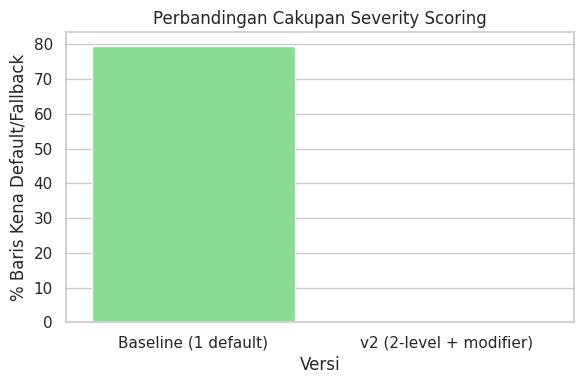

                     Versi  Persentase Fallback/Default (%)
0     Baseline (1 default)                        79.486258
1  v2 (2-level + modifier)                         0.000000


In [32]:
## Perbandingan Cakupan: Baseline vs Severity v2

# Baseline
pct_default_baseline = (df["severity"] == DEFAULT_SEVERITY).mean() * 100

# v2
pct_fallback_v2 = (df["Primary Type"].str.upper().isin(PRIMARY_TYPE_BASE.keys()) == False).mean() * 100

comparison = pd.DataFrame({
    "Versi": ["Baseline (1 default)", "v2 (2-level + modifier)"],
    "Persentase Fallback/Default (%)": [pct_default_baseline, pct_fallback_v2]
})

plt.figure(figsize=(6, 4))
sns.barplot(x="Versi", y="Persentase Fallback/Default (%)", data=comparison,
            hue="Versi", palette=["#7AEB89", "#FC6091"], legend=False)
plt.title("Perbandingan Cakupan Severity Scoring")
plt.ylabel("% Baris Kena Default/Fallback")
plt.tight_layout(); plt.show()

print(comparison)

In [33]:
severity_by_type = df.groupby("Primary Type")["severity_v2"].mean().sort_values(ascending=False)
print(severity_by_type)

Primary Type
HOMICIDE                             99.981395
CRIMINAL SEXUAL ASSAULT              99.580296
KIDNAPPING                           91.622642
OFFENSE INVOLVING CHILDREN           90.480000
HUMAN TRAFFICKING                    90.000000
ROBBERY                              83.943725
WEAPONS VIOLATION                    79.529799
ARSON                                71.381818
SEX OFFENSE                          70.914835
BATTERY                              55.655884
ASSAULT                              55.600699
STALKING                             50.572917
BURGLARY                             47.473684
INTIMIDATION                         45.000000
MOTOR VEHICLE THEFT                  38.452814
NARCOTICS                            35.000000
OTHER OFFENSE                        32.596870
OTHER NARCOTIC VIOLATION             30.000000
INTERFERENCE WITH PUBLIC OFFICER     30.000000
THEFT                                29.311687
CONCEALED CARRY LICENSE VIOLATION    25.000000


**Hasil akhir Severity Table:**

- **Cakupan penuh.** Persentase baris yang jatuh ke fallback dapat dibaca dari output di atas,
  dan turun drastis dibanding baseline yang memberikan satu nilai default seragam untuk mayoritas
  kombinasi.
- **Ranking konsisten dengan intuisi keamanan publik.** Kejahatan terhadap nyawa dan tubuh berada
  di puncak, kekerasan sedang serta properti berat di tengah, dan pelanggaran administratif di
  dasar. Urutan ini diperiksa untuk memastikan tidak ada anomali atau pembalikan yang tidak masuk
  akal.
- **Seluruh modifier terbukti aktif.** Cell verifikasi memastikan tidak ada aturan yang gagal
  diam-diam akibat ketidakcocokan format teks.


## 5.2 Temporal Decay: Recency

Apakah kejahatan 3 tahun lalu perlu berkontribusi sebesar kejahatan kemarin? Umumnya
**tidak**, relevansi cenderung memudar seiring waktu.

> 🔧 **Versi Sederhana (Baseline).** Menggunakan bentuk peluruhan **paling lugas**: bobot
> **linear** yang turun dari 1 (paling baru) hingga mendekati 0 (paling lama), berdasarkan
> umur kejadian.

In [34]:
REFERENCE_DATE = df["Datetime"].max()   # "sekarang" menurut data
df["age_days"] = (REFERENCE_DATE - df["Datetime"]).dt.total_seconds() / 86400

# Peluruhan LINEAR sederhana: 1.0 di hari terbaru -> ~0 di data tertua
max_age = df["age_days"].max()
df["w_time"] = 1 - (df["age_days"] / max_age)     # rentang 0..1

# Kontribusi tiap kejadian = severity x bobot recency
df["event_value"] = df["severity"] * df["w_time"]

print(f"Reference date : {REFERENCE_DATE}")
print(f"w_time range   : {df['w_time'].min():.3f} .. {df['w_time'].max():.3f}")
df[["Datetime", "age_days", "w_time", "severity", "event_value"]].head()

Reference date : 2026-04-10 23:56:00
w_time range   : 0.000 .. 1.000


,Datetime,age_days,w_time,severity,event_value
0,2026-04-10 23:56:00,0.000000,1.000000,30,30.000000
1,2026-04-10 23:30:00,0.018056,0.999978,30,29.999348
2,2026-04-10 23:29:00,0.018750,0.999977,30,29.999323
3,2026-04-10 23:00:00,0.038889,0.999953,30,29.998596
4,2026-04-10 22:50:00,0.045833,0.999945,30,29.998345


### Versi Dikembangkan: Temporal Decay dan Pemisahan Jendela Fitur versus Label

Ada dua keputusan yang saling terkait di bagian ini, dan keduanya harus diambil bersamaan agar
tidak saling bertabrakan.

#### Masalah pertama: label dan fitur dihitung dari kejadian yang sama

Pada versi sebelumnya, `crime_count` dan seluruh fitur agregat dihitung dari himpunan kejadian
yang persis sama dengan yang membentuk `risk_score`. Model yang dilatih di atas dataset seperti
itu akan mencapai akurasi sangat tinggi, tetapi bukan karena berhasil belajar apa pun, melainkan
karena input dan targetnya adalah dua cara menghitung angka yang sama. Ini tautologi, bukan
prediksi, dan merupakan bentuk kebocoran target yang paling umum.

**Solusi: pisahkan sumbu waktu.**

| Jendela | Rentang | Dipakai untuk |
| :-- | :-- | :-- |
| Historis | dari awal subset sampai titik potong | Seluruh fitur prediktor |
| Label | 180 hari terakhir | Perhitungan `risk_score` saja |

Dengan pembagian ini, pertanyaan yang dijawab dataset berubah menjadi pertanyaan yang benar secara
operasional: berdasarkan pola historis suatu lokasi dan waktu, seberapa berisiko lokasi itu
sekarang. Fitur berasal dari masa lalu, label berasal dari periode terkini, dan tidak ada satu
kejadian pun yang muncul di kedua sisi.

#### Masalah kedua: bentuk dan parameter peluruhan

Peluruhan linear pada baseline membuat kejadian tertua berbobot persis nol, seolah-olah sama
sekali tidak relevan. Titik nol itu juga bergeser mengikuti ukuran subset, bukan mengikuti alasan
substantif. Karena itu dipakai peluruhan eksponensial berbasis half-life:

$$w(t) = 0.5^{\frac{\text{age days}}{H}}$$

Bentuk ini turun mulus, tidak pernah benar-benar nol, dan parameternya punya arti yang bisa
langsung dijelaskan, yaitu berapa lama sebuah kejadian kehilangan separuh relevansinya.

**Parameter yang dipilih: jendela label 180 hari, half-life 90 hari.**

Kombinasi ini adalah revisi dari versi sebelumnya yang memakai half-life 45 hari di atas subset
tiga tahun. Kombinasi lama itu tidak koheren. Dengan half-life 45 hari pada rentang sekitar 830
hari, total bobot seluruh data hanya setara sekitar 65 hari data penuh, artinya lebih dari sembilan
puluh persen kejadian yang sudah susah payah dikumpulkan praktis tidak berkontribusi apa pun.
Justifikasi memilih subset tiga tahun agar pola musiman tidak bias pun menjadi batal dengan
sendirinya, karena pola musiman sudah terhapus oleh peluruhan sebelum sempat masuk ke label.

Pilihan sekarang menempatkan setiap parameter pada perannya masing-masing:

- **Jendela label 180 hari** cukup panjang untuk mengumpulkan kejadian yang memadai bagi sinyal
  spasial yang stabil, dan cukup pendek untuk tetap menggambarkan kondisi terkini.
- **Half-life 90 hari di dalam jendela tersebut** membuat kejadian bulan terakhir jelas lebih
  berbobot dibanding kejadian enam bulan lalu, tanpa membuat label bergantung pada segelintir
  kejadian minggu terakhir saja.
- **Sisa data historis tetap terpakai penuh tanpa peluruhan** sebagai basis fitur. Di sinilah
  subset tiga tahun akhirnya memberi manfaat nyata: karakter jangka panjang sebuah lokasi,
  termasuk pola musimannya, memang butuh rentang panjang untuk diestimasi dengan stabil.

Dengan kata lain, peluruhan cepat dipakai untuk menjawab seberapa berisiko sekarang, sedangkan
rentang panjang dipakai untuk menjawab lokasi seperti apa ini. Kedua pertanyaan itu memang menuntut
horizon waktu yang berbeda.


Reference date : 2026-04-10 23:56:00
Titik potong   : 2025-10-12 23:56:00
Jendela HISTORIS (fitur) : 116,419 baris (650 hari)
Jendela LABEL  (target)  : 28,284 baris (180 hari)
Irisan kedua jendela     : 0 (harus 0)

Distribusi bobot di dalam jendela label:
  Kejadian <=  30 hari menyumbang  29.1% bobot total
  Kejadian <=  60 hari menyumbang  50.7% bobot total
  Kejadian <=  90 hari menyumbang  66.6% bobot total
  Kejadian <= 180 hari menyumbang 100.0% bobot total


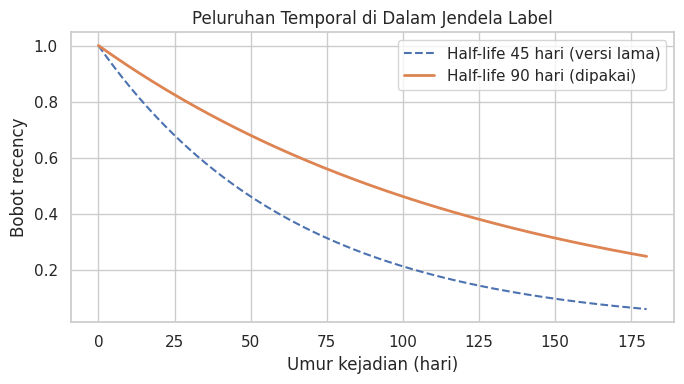

In [35]:
# ================= Pemisahan Jendela Fitur versus Label =================
REFERENCE_DATE    = df["Datetime"].max()
LABEL_WINDOW_DAYS = 180
HALF_LIFE_DAYS    = 90
CUTOFF = REFERENCE_DATE - pd.Timedelta(days=LABEL_WINDOW_DAYS)

df_label = df[df["Datetime"] >  CUTOFF].copy()   # membentuk risk_score
df_hist  = df[df["Datetime"] <= CUTOFF].copy()   # membentuk seluruh fitur

df_label["age_days"]    = (REFERENCE_DATE - df_label["Datetime"]).dt.total_seconds() / 86400
df_label["w_time"]      = 0.5 ** (df_label["age_days"] / HALF_LIFE_DAYS)
df_label["event_value"] = df_label["severity_v2"] * df_label["w_time"]

print(f"Reference date : {REFERENCE_DATE}")
print(f"Titik potong   : {CUTOFF}")
print(f"Jendela HISTORIS (fitur) : {len(df_hist):,} baris "
      f"({(CUTOFF - df['Datetime'].min()).days} hari)")
print(f"Jendela LABEL  (target)  : {len(df_label):,} baris "
      f"({LABEL_WINDOW_DAYS} hari)")

irisan = len(set(df_hist["ID"]) & set(df_label["ID"]))
print(f"Irisan kedua jendela     : {irisan} (harus 0)")
assert irisan == 0, "Ada kejadian yang muncul di kedua jendela, kebocoran target"

# Efektivitas bobot: berapa persen bobot total disumbang tiap rentang umur
print("\nDistribusi bobot di dalam jendela label:")
for d in [30, 60, 90, 180]:
    share = df_label.loc[df_label["age_days"] <= d, "w_time"].sum() / df_label["w_time"].sum()
    print(f"  Kejadian <= {d:>3} hari menyumbang {share * 100:5.1f}% bobot total")

fig, ax = plt.subplots(figsize=(7, 4))
ages = np.linspace(0, LABEL_WINDOW_DAYS, 200)
ax.plot(ages, 0.5 ** (ages / 45), ls="--", label="Half-life 45 hari (versi lama)")
ax.plot(ages, 0.5 ** (ages / HALF_LIFE_DAYS), lw=2,
        label=f"Half-life {HALF_LIFE_DAYS} hari (dipakai)")
ax.set_xlabel("Umur kejadian (hari)"); ax.set_ylabel("Bobot recency")
ax.set_title("Peluruhan Temporal di Dalam Jendela Label")
ax.legend(); plt.tight_layout(); plt.show()


### 5.2b Membentuk Tabel Unit Analisis yang Lengkap

#### Kenapa `groupby` saja tidak cukup

Membentuk tabel unit langsung dari `groupby` menghasilkan cacat yang mudah terlewat namun
berakibat fatal. `groupby` hanya mengembalikan kombinasi yang benar-benar muncul di data, sehingga
tabel yang dihasilkan **hanya berisi lokasi dan waktu yang ada kejahatannya**.

Ruang unit yang sesungguhnya adalah seluruh kombinasi sel dikali 7 hari dikali 24 jam. Kombinasi
yang teramati hanya sebagian kecil darinya, dan sisanya hilang tanpa jejak. Akibatnya:

- Kolom jumlah kejadian tidak pernah bernilai nol, karena baris nol memang tidak pernah dibuat.
- Tier hijau berubah makna menjadi sepertiga paling ringan di antara lokasi dan waktu yang tetap
  ada kejahatannya, bukan aman.
- Model tidak punya satu pun contoh negatif untuk dipelajari, sehingga tidak akan pernah bisa
  menyimpulkan bahwa suatu lokasi pada jam tertentu aman.
- Aplikasi harus melayani pertanyaan untuk sembarang lokasi dan jam, sehingga mayoritas pertanyaan
  pengguna jatuh ke unit yang tidak pernah ada di data latih.

Perbaikannya adalah membangun grid penuh lebih dulu lewat perkalian kartesian, lalu menempelkan
hasil agregasi ke atasnya, dan mengisi kombinasi yang tidak teramati dengan nol. Nol di sini adalah
informasi yang sah, yaitu tidak ada kejadian tercatat, bukan data yang hilang.

#### Menangani sparsity dengan penyusutan empiris

Grid penuh memunculkan konsekuensi baru. Sebagian besar unit hanya berisi nol, dan unit yang terisi
biasanya hanya memuat satu atau dua kejadian. Menghitung profil per jam untuk setiap sel secara
langsung akan menghasilkan angka yang lebih banyak mencerminkan kebetulan daripada pola nyata.

Solusinya adalah **penyusutan empiris** (empirical Bayes shrinkage), yang menggabungkan dua sumber
informasi:

$$\text{value}_{c,d,h} = \alpha_c \cdot \text{observed}_{c,d,h} + (1 - \alpha_c) \cdot \text{total}_c \cdot \text{share}_{d,h}$$

- `observed` adalah nilai yang benar-benar teramati di sel tersebut pada hari dan jam tersebut.
- `total` adalah total nilai sel sepanjang jendela label, yang jauh lebih stabil karena mengumpulkan
  seluruh kejadian di sel itu.
- `share` adalah profil temporal global, yaitu proporsi risiko yang jatuh pada tiap kombinasi hari
  dan jam ketika dihitung dari seluruh area studi. Profil ini punya basis data yang sangat besar
  sehingga bentuknya halus dan dapat dipercaya.
- $\alpha_c = n_c / (n_c + K)$ adalah bobot kepercayaan yang bergerak sendiri mengikuti jumlah
  kejadian di sel tersebut.

Perilakunya persis seperti yang diinginkan. Sel dengan banyak kejadian punya $\alpha$ mendekati satu
sehingga pola temporal khasnya dipertahankan. Sel dengan sedikit kejadian punya $\alpha$ mendekati
nol sehingga profilnya meminjam bentuk dari pola global alih-alih mengikuti satu dua kejadian yang
kebetulan tercatat. Tidak ada ambang batas keras yang perlu ditentukan, karena peralihannya
berlangsung mulus.

Pendekatan ini sekaligus menjawab kelemahan yang sebelumnya hanya diserahkan pada penghalusan
spasial. Sparsity kini ditangani pada dua sumbu sekaligus, temporal lewat penyusutan di sini dan
spasial lewat kernel pada bagian berikutnya.


In [36]:
# ================= Grid Unit Lengkap dan Penyusutan Empiris =================
ALL_CELLS   = np.sort(df["cell_id"].unique())
n_cells     = len(ALL_CELLS)
cell_to_idx = {c: i for i, c in enumerate(ALL_CELLS)}
N_SLOTS     = 7 * 24

full_grid = pd.MultiIndex.from_product(
    [ALL_CELLS, range(7), range(24)], names=["cell_id", "dow", "hour"]
).to_frame(index=False)

obs = (df_label.groupby(["cell_id", "dow", "hour"], as_index=False)
       .agg(obs_value=("event_value", "sum"), obs_count=("ID", "size")))

unit = full_grid.merge(obs, on=["cell_id", "dow", "hour"], how="left")
unit[["obs_value", "obs_count"]] = unit[["obs_value", "obs_count"]].fillna(0)

# Koordinat centroid sel ikut dibawa, karena grid penuh dibentuk dari daftar cell_id
# saja dan tidak lagi mewarisi kolom lat_r / lon_r dari hasil groupby.
coords_lookup = df[["cell_id", "lat_r", "lon_r"]].drop_duplicates("cell_id")
unit = unit.merge(coords_lookup, on="cell_id", how="left")
assert unit[["lat_r", "lon_r"]].isna().sum().sum() == 0, "Ada sel tanpa koordinat"

coverage = len(obs) / len(unit) * 100
print(f"Ruang unit penuh   : {len(unit):,} baris ({n_cells:,} sel x {N_SLOTS} slot waktu)")
print(f"Unit yang teramati : {len(obs):,} ({coverage:.1f}%)")
print(f"Unit bernilai nol  : {len(unit) - len(obs):,} ({100 - coverage:.1f}%)")

# Komponen penyusutan empiris
cell_total = df_label.groupby("cell_id")["event_value"].sum()
cell_n     = df_label.groupby("cell_id")["ID"].size()
unit["cell_total"] = unit["cell_id"].map(cell_total).fillna(0.0)
unit["cell_n"]     = unit["cell_id"].map(cell_n).fillna(0).astype(int)

global_share = (df_label.groupby(["dow", "hour"])["event_value"].sum()
                / df_label["event_value"].sum()).rename("global_share").reset_index()
unit = unit.merge(global_share, on=["dow", "hour"], how="left")
unit["global_share"] = unit["global_share"].fillna(1 / N_SLOTS)

K_SHRINK = 50   # jumlah kejadian saat sebuah sel dianggap separuh bisa dipercaya sendiri
unit["alpha"] = unit["cell_n"] / (unit["cell_n"] + K_SHRINK)
unit["base_value"] = (unit["alpha"] * unit["obs_value"]
                      + (1 - unit["alpha"]) * unit["cell_total"] * unit["global_share"])

alpha_cell = unit.groupby("cell_id")["alpha"].first()
print(f"\nAlpha per sel: min {alpha_cell.min():.3f}, median {alpha_cell.median():.3f}, "
      f"max {alpha_cell.max():.3f}")
print(f"Sel yang lebih percaya profil global (alpha < 0.5): "
      f"{(alpha_cell < 0.5).mean() * 100:.1f}%")
print("\nbase_value:")
print(unit["base_value"].describe().round(4).to_string())


Ruang unit penuh   : 1,089,480 baris (6,485 sel x 168 slot waktu)
Unit yang teramati : 25,241 (2.3%)
Unit bernilai nol  : 1,064,239 (97.7%)

Alpha per sel: min 0.000, median 0.038, max 0.878
Sel yang lebih percaya profil global (alpha < 0.5): 99.3%

base_value:
count    1.089480e+06
mean     5.566000e-01
std      1.843900e+00
min      0.000000e+00
25%      0.000000e+00
50%      1.952000e-01
75%      5.429000e-01
max      1.971604e+02


### Tabel Unit Versi Baseline (hanya sebagai pembanding)

Tabel di bawah dibentuk dengan cara baseline, yaitu `groupby` langsung tanpa grid penuh dan tanpa
penyusutan empiris. Tabel ini **tidak dipakai** pada pipeline utama dan hanya disimpan sebagai
pembanding untuk memperlihatkan perbedaan hasil pada Bagian 5.3 dan 5.4.

Perhatikan bahwa `crime_count` di sini minimalnya selalu satu, karena `groupby` tidak pernah
menghasilkan baris untuk kombinasi yang tidak ada kejadiannya. Inilah tepatnya masalah yang
diperbaiki oleh grid penuh di Bagian 5.2b.


In [37]:
# PERBAIKAN: pakai nama variabel terpisah supaya TIDAK menimpa `unit` yang sudah
# dibangun dari severity_v2 + exponential decay di atas. Tabel ini hanya dipakai
# sebagai pembanding baseline di 5.3, bukan untuk pipeline utama.
unit_baseline = (df.groupby(["cell_id", "lat_r", "lon_r", "dow", "hour"], as_index=False)
                    .agg(base_value  = ("event_value", "sum"),
                         crime_count = ("ID", "size")))
print("Jumlah baris unit_baseline (sel × hari × jam):", f"{len(unit_baseline):,}")
unit_baseline.head()

Jumlah baris unit_baseline (sel × hari × jam): 107,959


,cell_id,lat_r,lon_r,dow,hour,base_value,crime_count
0,41.717_-87.623,41.717,-87.623,1,17,1.831762,1
1,41.717_-87.623,41.717,-87.623,1,18,24.070598,1
2,41.717_-87.623,41.717,-87.623,3,4,14.227881,1
3,41.717_-87.623,41.717,-87.623,4,9,25.934901,1
4,41.717_-87.623,41.717,-87.623,6,0,18.160199,1


### 5.2c Fitur Prediktor dari Jendela Historis

Seluruh fitur dihitung **hanya dari `df_hist`**, yaitu kejadian sebelum titik potong. Tidak ada satu
pun kejadian di jendela label yang menyentuh sisi fitur. Inilah yang membuat dataset ini benar-benar
bisa disebut dataset prediksi, bukan sekadar dataset perhitungan ulang.

**Level agregasi: per sel, bukan per sel kali hari kali jam.**

Percobaan menghitung keragaman kejahatan dan proporsi penangkapan di level sel kali hari kali jam
menghasilkan fitur yang praktis konstan, karena rata-rata hanya ada satu sampai dua kejadian per
unit. Keragaman jenis kejahatan hampir selalu bernilai satu, dan proporsi penangkapan runtuh menjadi
biner nol atau satu yang ditentukan nasib satu kejadian.

Secara domain pun kedua besaran ini memang merupakan karakteristik tempat. Seberapa beragam
kejahatan di suatu lokasi adalah sifat lingkungan yang terbentuk lintas bulan, bukan sifat yang
berbeda antara pukul sepuluh dan pukul sebelas.

**Fitur yang dibentuk:**

| Fitur | Arti | Alasan relevan |
| :-- | :-- | :-- |
| `hist_crime_count` | Jumlah kejadian historis di sel | Basis intensitas jangka panjang lokasi |
| `crime_diversity` | Jumlah jenis kejahatan berbeda | Lokasi dengan banyak ragam kejahatan lebih sulit diprediksi dibanding lokasi yang didominasi satu jenis ringan berulang |
| `violent_share` | Proporsi kejahatan dengan kontak fisik | Membedakan lokasi rawan pencurian properti dari lokasi rawan kekerasan terhadap orang, dan yang kedua jauh lebih relevan untuk keselamatan pejalan kaki |
| `night_share` | Proporsi kejadian pukul 22 sampai 04 | Menandai lokasi yang risikonya terkonsentrasi di malam hari |
| `street_share` | Proporsi kejadian di ruang terbuka publik | Memakai `Location Description`, membedakan risiko yang dialami pejalan kaki dari risiko di dalam bangunan privat |
| `seasonal_cv` | Koefisien variasi jumlah kejadian antar bulan | Menandai lokasi yang polanya musiman tajam versus rata sepanjang tahun |
| `peak_month_sin`, `peak_month_cos` | Encoding siklikal bulan puncak | Menyimpan informasi kapan lokasi biasanya paling rawan tanpa memecah unit analisis |
| `dominant_crime_type` | Jenis kejahatan paling sering | Menjawab pertanyaan pengguna tentang alasan sebuah titik ditandai merah |

**Koreksi bias musiman.**

Subset mencakup dua tahun penuh ditambah tahun berjalan yang baru terisi sebagian. Akibatnya,
bulan-bulan awal tahun memiliki lebih banyak tahun data dibanding bulan-bulan akhir tahun.
Menghitung bulan puncak langsung dari jumlah mentah akan menghasilkan bias sistematis ke bulan awal,
sehingga `peak_month` justru merekam artefak pengumpulan data alih-alih pola musiman yang
sesungguhnya. Karena itu jumlah kejadian per bulan dinormalisasi dulu terhadap banyaknya tahun yang
tersedia untuk bulan tersebut, sebelum bulan puncak dan koefisien variasi dihitung.

**`arrest_rate` tidak disertakan.**

Alasannya bukan karena sistem tidak terhubung ke data kepolisian, sebab seluruh dataset ini justru
berasal dari kepolisian. Alasan sebenarnya adalah arah hubungannya ambigu. Tingkat penangkapan yang
tinggi bisa berarti penegakan hukum aktif sehingga lokasi lebih aman, tetapi bisa juga berarti
banyak kejahatan serius memang terjadi di sana. Karena tandanya tidak dapat ditentukan dari data
ini, memasukkannya hanya akan mempersulit interpretasi model.


In [38]:
# ================= Fitur Prediktor, seluruhnya dari df_hist =================
VIOLENT_TYPES = {
    "HOMICIDE", "CRIMINAL SEXUAL ASSAULT", "CRIM SEXUAL ASSAULT", "ROBBERY",
    "BATTERY", "ASSAULT", "WEAPONS VIOLATION", "KIDNAPPING", "SEX OFFENSE",
    "HUMAN TRAFFICKING", "ARSON",
}
PUBLIC_SPACE = ["STREET", "SIDEWALK", "ALLEY", "PARKING", "CTA", "PARK"]

df_hist["is_violent"] = df_hist["Primary Type"].str.upper().isin(VIOLENT_TYPES)
df_hist["is_night"]   = df_hist["hour"].isin([22, 23, 0, 1, 2, 3, 4])
df_hist["is_street"]  = (df_hist["Location Description"].fillna("")
                         .str.upper().str.contains("|".join(PUBLIC_SPACE)))

cell_feat = (df_hist.groupby("cell_id").agg(
    hist_crime_count = ("ID", "size"),
    crime_diversity  = ("Primary Type", "nunique"),
    violent_share    = ("is_violent", "mean"),
    night_share      = ("is_night", "mean"),
    street_share     = ("is_street", "mean"),
).reset_index())

# Jenis kejahatan dominan, untuk menjelaskan alasan sebuah titik ditandai merah
dominant = (df_hist.groupby(["cell_id", "Primary Type"]).size()
            .reset_index(name="n")
            .sort_values("n", ascending=False)
            .drop_duplicates("cell_id")[["cell_id", "Primary Type"]]
            .rename(columns={"Primary Type": "dominant_crime_type"}))

# Fitur musiman dengan koreksi bias jumlah tahun per bulan
years_per_month = df_hist.groupby("month")["Year"].nunique()
monthly      = df_hist.groupby(["cell_id", "month"]).size().unstack(fill_value=0)
monthly_norm = monthly.div(years_per_month.reindex(monthly.columns).values, axis=1)

seasonal = pd.DataFrame({
    "cell_id": monthly_norm.index,
    "seasonal_cv": (monthly_norm.std(axis=1)
                    / monthly_norm.mean(axis=1).replace(0, np.nan)).fillna(0).values,
    "peak_month": monthly_norm.idxmax(axis=1).values,
})
seasonal["peak_month_sin"], seasonal["peak_month_cos"] = cyclical_encode(
    seasonal["peak_month"], 12)

print("Distribusi bulan puncak SETELAH koreksi bias jumlah tahun:")
print(seasonal["peak_month"].value_counts().sort_index().to_string())

# Gabungkan ke unit. Sel tanpa riwayat historis diisi nol, bukan NaN, karena tidak adanya
# kejadian adalah informasi yang sah dan bukan data yang hilang.
cell_features = (cell_feat
                 .merge(dominant, on="cell_id", how="left")
                 .merge(seasonal.drop(columns="peak_month"), on="cell_id", how="left"))

NUM_HIST_COLS = ["hist_crime_count", "crime_diversity", "violent_share", "night_share",
                 "street_share", "seasonal_cv", "peak_month_sin", "peak_month_cos"]

unit = unit.merge(cell_features, on="cell_id", how="left")
unit[NUM_HIST_COLS] = unit[NUM_HIST_COLS].fillna(0)
unit["dominant_crime_type"] = unit["dominant_crime_type"].fillna("NONE")

print("\nRingkasan fitur historis di level sel:")
print(cell_features[NUM_HIST_COLS].describe().round(3).to_string())


Distribusi bulan puncak SETELAH koreksi bias jumlah tahun:
peak_month
1     686
2     579
3     642
4     525
5     588
6     569
7     588
8     512
9     431
10    188
11    560
12    469

Ringkasan fitur historis di level sel:
       hist_crime_count  crime_diversity  violent_share  night_share  street_share  seasonal_cv  peak_month_sin  peak_month_cos
count          6337.000         6337.000       6337.000     6337.000      6337.000     6337.000        6337.000        6337.000
mean             18.371            5.393          0.306        0.246         0.523        1.544           0.098          -0.028
std              36.804            3.482          0.264        0.230         0.302        0.914           0.685           0.722
min               1.000            1.000          0.000        0.000         0.000        0.115          -1.000          -1.000
25%               3.000            3.000          0.077        0.058         0.312        0.853          -0.500          -0.866
50

## 5.3 Spatial Aggregation: Proximity

Risiko sebuah titik idealnya **tidak hanya** ditentukan oleh kejahatan tepat di sel itu,
area di sekitarnya juga relevan. Menyebarkan pengaruh antar-sel tetangga (*spatial smoothing*)
adalah teknik yang umum.

> 🔧 **Versi Sederhana (Baseline).** Lakukan penghalusan spasial **paling kasar**:
> untuk tiap sel, ambil **rata-rata `base_value` sel itu sendiri + 8 sel tetangga langsung**
> (grid 3×3 di sekelilingnya), pada irisan hari×jam yang sama. Gunakan indeks grid dari
> koordinat bulat, **tanpa perhitungan jarak sesungguhnya**. Sederhana, jalan, dan sudah
> menangkap ide "tetangga ikut berpengaruh", tapi masih kasar (semua tetangga dibobot sama,
> radius tetap 1 sel).

In [39]:
STEP = 10 ** (-ROUND_DECIMALS)
unit_baseline["gx"] = (unit_baseline["lat_r"] / STEP).round().astype(int)
unit_baseline["gy"] = (unit_baseline["lon_r"] / STEP).round().astype(int)

base_lookup = unit_baseline.set_index(["gx", "gy", "dow", "hour"])["base_value"].to_dict()

def smooth_neighbors(r):
    vals = []
    for dx in (-1, 0, 1):
        for dy in (-1, 0, 1):
            v = base_lookup.get((r.gx + dx, r.gy + dy, r.dow, r.hour))
            if v is not None:
                vals.append(v)
    return np.mean(vals) if vals else r.base_value

unit_baseline["risk_raw"] = [smooth_neighbors(r) for r in unit_baseline.itertuples()]
print("risk_raw range:", round(unit_baseline["risk_raw"].min(), 2), "..",
      round(unit_baseline["risk_raw"].max(), 2))
unit_baseline[["cell_id", "dow", "hour", "base_value", "risk_raw"]].head()

risk_raw range: 0.0 .. 273.13


,cell_id,dow,hour,base_value,risk_raw
0,41.717_-87.623,1,17,1.831762,1.831762
1,41.717_-87.623,1,18,24.070598,24.070598
2,41.717_-87.623,3,4,14.227881,14.227881
3,41.717_-87.623,4,9,25.934901,25.934901
4,41.717_-87.623,6,0,18.160199,18.160199


### Versi Dikembangkan: Spatial Smoothing dengan BallTree + Haversine + Gaussian Kernel

**1. Bobot berdasarkan jarak:**

Diganti dari bobot rata-rata sama (baseline) menjadi **kernel Gaussian** berdasarkan jarak haversine sesungguhnya:
$$w = \exp(-d^2 / (2\sigma^2))$$
Jarak dihitung pakai `sklearn.neighbors.BallTree` dengan metric `haversine` bukan estimasi jarak dari indeks grid seperti baseline. Sel yang lebih dekat otomatis mendapat bobot lebih besar, dan bobot turun mulus (bukan seragam lalu terpotong tiba-tiba di batas radius).

**2. Radius pengaruh:**

Diganti dari kaku 1 sel (grid 3x3) menjadi radius eksplisit `RADIUS_KM = 0.4` km. Alasan tidak lagi memakai 3x3: sejak grid diubah ke 3 desimal (~110m/sel), radius 3x3 hanya menjangkau ~330m terlalu sempit untuk merepresentasikan "lingkungan" yang bermakna secara risiko kejahatan. Radius 1,5 km (dengan `SIGMA_KM = 0.15` supaya pengaruh signifikan `w > 0.05` terkonsentrasi di ~1-2 blok kota) dipilih sebagai skala "neighborhood" yang wajar, sekaligus mengatasi sparsity data pada grid halus, sel dengan sedikit kejadian dapat "meminjam" sinyal dari lebih banyak sel tetangga dibanding radius 3x3 yang sempit.

**3. Bentuk agregasi:**

Dipakai **rata-rata berbobot** (weighted average), bukan jumlah
berbobot (weighted sum). Alasannya: `base_value` sudah merupakan **hasil penjumlahan**
severity x decay dari seluruh kejadian di satu sel (Section 5.2), kalau antar-tetangga dijumlahkan lagi (bukan dirata-rata), sel yang kebetulan dikelilingi banyak tetangga akan mendapat `risk_raw` yang jauh lebih besar semata karena densitas tetangganya tinggi, bukan karena risikonya sungguh lebih tinggi. Rata-rata berbobot menjaga skala
`risk_raw` tetap sebanding antar sel terlepas dari berapa banyak tetangga yang ada di sekitarnya.

**4. Koreksi penting pada penyebut rata-rata berbobot.**

Versi sebelumnya menyusun vektor penanda hanya untuk sel yang punya kejadian pada kombinasi hari
dan jam yang sedang diproses. Akibatnya penyebut rata-rata berbobot hanya menjumlahkan tetangga
yang kebetulan ada kejadiannya, sementara tetangga yang sepi diperlakukan seolah tidak ada.

Efeknya adalah pelebihan risiko yang sistematis. Sebuah sel yang dikelilingi ratusan tetangga,
namun hanya tiga di antaranya ada kejadian pada jam tersebut, akan mendapat nilai rata-rata dari
tiga sel itu saja. Yang terhitung menjadi rata-rata keparahan di tempat kejahatan terjadi, bukan
tingkat risiko wilayah. Kesalahan ini paling parah justru pada jam-jam sepi, yaitu dini hari, yang
merupakan jam paling penting bagi aplikasi keselamatan.

Perbaikannya sederhana namun mengubah hasil secara signifikan. Penyebut dihitung dari seluruh sel
tetangga tanpa kecuali, sehingga tetangga yang tidak ada kejadiannya ikut menekan nilai rata-rata
ke bawah sebagaimana mestinya. Karena tabel unit kini berbentuk grid penuh, penyebut ini bahkan
konstan dan cukup dihitung sekali di luar perulangan.

**5. Radius dipilih lewat perbandingan, bukan ditebak.**

Radius diuji pada beberapa nilai dan dinilai dari rasio simpangan baku sesudah terhadap sebelum
penghalusan. Rasio yang terlalu kecil menandakan variasi lokal ikut terhapus, sehingga peta risiko
menjadi rata dan kehilangan gunanya untuk membedakan rute. Rasio yang terlalu besar menandakan
penghalusan nyaris tidak bekerja, sehingga sparsity spasial tidak tertangani.


In [40]:
# ================= Spatial Smoothing, versi final =================
from scipy.sparse import coo_matrix

EARTH_R_KM = 6371.0

cell_coords = (df[["cell_id", "lat_r", "lon_r"]]
               .drop_duplicates("cell_id")
               .set_index("cell_id").loc[ALL_CELLS].reset_index())
coords_rad = np.radians(cell_coords[["lat_r", "lon_r"]].values)
tree = BallTree(coords_rad, metric="haversine")

# Urutkan unit agar bisa direshape menjadi matriks (n_cells x N_SLOTS)
unit["cell_idx"] = unit["cell_id"].map(cell_to_idx)
unit = unit.sort_values(["cell_idx", "dow", "hour"]).reset_index(drop=True)
assert len(unit) == n_cells * N_SLOTS, "Grid tidak lengkap, cek pembentukan unit"
V = unit["base_value"].values.reshape(n_cells, N_SLOTS)

def build_W(radius_km, sigma_km):
    idxs, dists = tree.query_radius(coords_rad, r=radius_km / EARTH_R_KM,
                                    return_distance=True)
    rows, cols, vals = [], [], []
    for i, (ix, dr) in enumerate(zip(idxs, dists)):
        w = np.exp(-((dr * EARTH_R_KM) ** 2) / (2 * sigma_km ** 2))
        rows.extend([i] * len(ix)); cols.extend(ix); vals.extend(w)
    return coo_matrix((vals, (rows, cols)), shape=(n_cells, n_cells)).tocsr()

def smooth(W):
    # KOREKSI: penyebut memakai SELURUH sel tetangga, termasuk yang tidak ada kejadiannya,
    # sehingga sel sepi ikut menurunkan rata-rata sebagaimana mestinya.
    denom = np.asarray(W.sum(axis=1)).ravel()
    return W.dot(V) / denom[:, None]

print(f"{'radius':>8} {'sigma':>7} {'tetangga':>10} {'std sesudah':>13} {'rasio std':>11}")
candidates = [(0.3, 0.12), (0.4, 0.15), (0.6, 0.25), (1.0, 0.40)]
results = {}
for r_km, s_km in candidates:
    W_try = build_W(r_km, s_km)
    S_try = smooth(W_try)
    ratio = S_try.std() / V.std()
    results[(r_km, s_km)] = (W_try, S_try, ratio)
    print(f"{r_km:>8.1f} {s_km:>7.2f} {W_try.nnz / n_cells:>10.1f} "
          f"{S_try.std():>13.4f} {ratio:>11.3f}")

RADIUS_KM, SIGMA_KM = 0.4, 0.15
W, S, ratio = results[(RADIUS_KM, SIGMA_KM)]
unit["risk_raw"] = S.reshape(-1)

print(f"\nDipilih radius {RADIUS_KM} km, sigma {SIGMA_KM} km "
      f"(rata-rata {W.nnz / n_cells:.1f} tetangga per sel)")
print(f"Rasio simpangan baku sesudah terhadap sebelum: {ratio:.3f}")
print("\nrisk_raw:")
print(unit["risk_raw"].describe().round(4).to_string())


  radius   sigma   tetangga   std sesudah   rasio std
     0.3    0.12       21.7        0.7033       0.381
     0.4    0.15       36.1        0.6250       0.339
     0.6    0.25       72.2        0.5100       0.277
     1.0    0.40      150.2        0.4441       0.241

Dipilih radius 0.4 km, sigma 0.15 km (rata-rata 36.1 tetangga per sel)
Rasio simpangan baku sesudah terhadap sebelum: 0.339

risk_raw:
count    1.089480e+06
mean     5.656000e-01
std      6.250000e-01
min      2.300000e-03
25%      2.219000e-01
50%      3.938000e-01
75%      6.800000e-01
max      1.860360e+01


## 5.4 Normalisasi → Risk Score 0–100

`risk_raw` biasanya sangat *skewed* (sebagian besar kecil, sedikit sangat besar). Agar
menjadi skor 0–100 yang stabil, kita perlu menormalisasinya.

> 🔧 **Versi Sederhana (Baseline).** Kita pakai **min–max scaling** langsung ke rentang
> 0–100. Cepat dan mudah — tapi rentan terhadap *outlier* (satu sel ekstrem bisa menekan
> semua sel lain ke bawah).

count    107959.00
mean          7.20
std           5.43
min           0.00
25%           3.81
50%           6.30
75%           9.17
max         100.00
Name: risk_score, dtype: float64


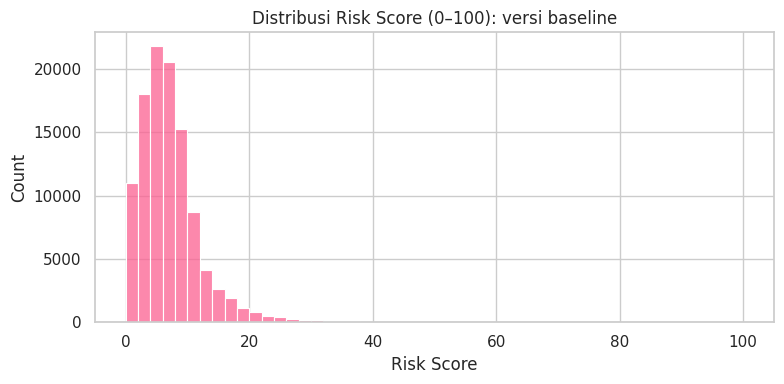

In [41]:
rr = unit_baseline["risk_raw"]
unit_baseline["risk_score"] = 100 * (rr - rr.min()) / (rr.max() - rr.min())
print(unit_baseline["risk_score"].describe().round(2))

plt.figure(figsize=(8, 4))
sns.histplot(unit_baseline["risk_score"], bins=50, color="#FC6091")
plt.title("Distribusi Risk Score (0–100): versi baseline")
plt.xlabel("Risk Score")
plt.tight_layout(); plt.show()

> **Normalisasi.** Perhatikan histogram di atas. Bentuknya sangat
> *skewed* (mayoritas nilai menumpuk di satu sisi), min–max langsung kurang ideal karena
> beberapa sel ekstrem menekan sisanya. Metode lain yang bisa kalian pertimbangkan &
> justifikasi: kompresi **`log1p`** sebelum scaling, **peringkat persentil**, atau *clipping*
> pada kuantil atas sebelum normalisasi. Bandingkan distribusinya dan pilih yang paling masuk
> akal untuk merepresentasikan "risiko".

### Versi Dikembangkan, Normalisasi dengan `log1p` sebelum Min-Max

**Masalah min-max langsung.**

Distribusi `risk_raw` sangat timpang ke kanan, yaitu mayoritas sel bernilai kecil dan segelintir
sel bernilai jauh lebih besar. Kalau nilai itu langsung di-min-max-kan, sel-sel ekstrem akan
menekan hampir seluruh sel lain ke rentang skor yang sangat sempit di ujung bawah, sehingga risiko
rendah dan risiko sedang menjadi sulit dibedakan.

**Solusi dan alasan memilihnya.**

Nilai dikompresi dulu dengan `log1p`, yang menstabilkan varians tanpa mengubah urutan risiko, baru
kemudian di-min-max-kan ke rentang 0 sampai 100. `log1p` dipilih dibanding dua alternatif lain:

- Dibanding **peringkat persentil**, `log1p` mempertahankan informasi magnitude, yaitu seberapa
  jauh jarak risiko antar sel, bukan sekadar urutannya. Ini penting karena Risk Score dimaksudkan
  merepresentasikan besaran risiko.
- Dibanding **clipping kuantil atas**, `log1p` tidak membuang informasi apa pun dari sel ekstrem
  dan hanya mengompresnya secara proporsional. Clipping akan menyamakan seluruh sel di atas kuantil
  tertentu, sehingga justru menghilangkan granularitas di area paling berisiko, padahal area itulah
  yang paling penting untuk dibedakan.

**Dua skala untuk dua peran yang berbeda.**

Kompresi logaritmik punya konsekuensi yang perlu diantisipasi. Karena ekor atas dipadatkan,
sebagian besar unit akan menempati separuh bawah rentang 0 sampai 100, dan skor tinggi menjadi
sangat jarang muncul. Untuk model hal ini tidak masalah, tetapi bagi pengguna aplikasi skor seperti
ini menyesatkan, karena nilai yang sebenarnya median akan terbaca sangat aman.

Karena itu disimpan dua kolom dengan peran berbeda:

- `risk_score`, hasil `log1p` dan min-max, yang mempertahankan magnitude dan dipakai sebagai target
  model.
- `risk_score_display`, peringkat persentil, yang tersebar merata sepanjang 0 sampai 100 dan lebih
  intuitif untuk ditampilkan kepada pengguna.


risk_score (magnitude, dipakai model):
count    1089480.00
mean          13.39
std            9.53
min            0.00
25%            6.67
50%           11.10
75%           17.39
max          100.00
Skewness: 1.76

Pemakaian rentang skala:
  Unit dengan skor > 20: 18.44%
  Unit dengan skor > 40:  2.20%
  Unit dengan skor > 50:  0.73%
  Unit dengan skor > 60:  0.24%
  Unit dengan skor > 80:  0.02%


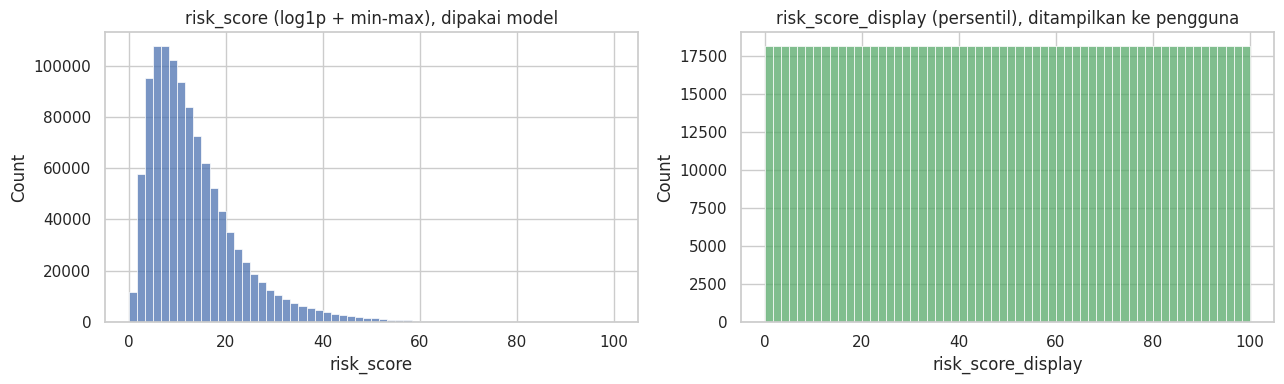

In [42]:
# ================= Normalisasi menjadi dua skala dengan peran berbeda =================
rr = unit["risk_raw"]
rr_log = np.log1p(rr - rr.min())
unit["risk_score"] = 100 * (rr_log - rr_log.min()) / (rr_log.max() - rr_log.min())

# Skala persentil, untuk ditampilkan ke pengguna
unit["risk_score_display"] = rr.rank(pct=True) * 100

print("risk_score (magnitude, dipakai model):")
print(unit["risk_score"].describe().round(2).to_string())
print(f"Skewness: {unit['risk_score'].skew():.2f}")

# Diagnosis pemakaian skala: berapa persen unit yang skornya di atas tiap ambang
print("\nPemakaian rentang skala:")
for t in [20, 40, 50, 60, 80]:
    print(f"  Unit dengan skor > {t:>2}: {(unit['risk_score'] > t).mean() * 100:5.2f}%")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(unit["risk_score"], bins=60, ax=axes[0], color="#4C72B0")
axes[0].set_title("risk_score (log1p + min-max), dipakai model")
sns.histplot(unit["risk_score_display"], bins=60, ax=axes[1], color="#55A868")
axes[1].set_title("risk_score_display (persentil), ditampilkan ke pengguna")
plt.tight_layout(); plt.show()


**Membaca bentuk distribusi:**

Distribusi `risk_score` timpang ke kanan, yaitu menumpuk di nilai rendah dengan ekor panjang yang
tipis. Bentuk ini bukan cacat, melainkan gambaran yang memang diharapkan.

Dua sebabnya:

1. **Grid unit kini lengkap.** Mayoritas kombinasi lokasi dan jam di area sekitar stasiun memang
   tidak punya kejadian tercatat sama sekali. Setelah unit kosong ikut masuk, wajar bila massa
   distribusi berkumpul di nilai rendah. Justru distribusi yang simetris di sini akan mencurigakan,
   karena berarti unit sepi ikut terangkat oleh penghalusan yang terlalu agresif.
2. **Radius penghalusan sengaja dipilih kecil.** Radius yang besar akan meratakan hotspot bersama
   area sepi menjadi tingkat risiko sedang di mana-mana, yang justru menghapus informasi paling
   berguna bagi Safe Route Recommendation.

Bentuk timpang inilah yang menjadi alasan kuat mengapa kategorisasi tiga tier memakai ambang batas
berbasis persentil, bukan angka absolut yang dibagi rata.


### Visualisasi peta risiko
Rata-rata Risk Score per sel — memastikan hasilnya sejalan dengan hotspot di EDA.

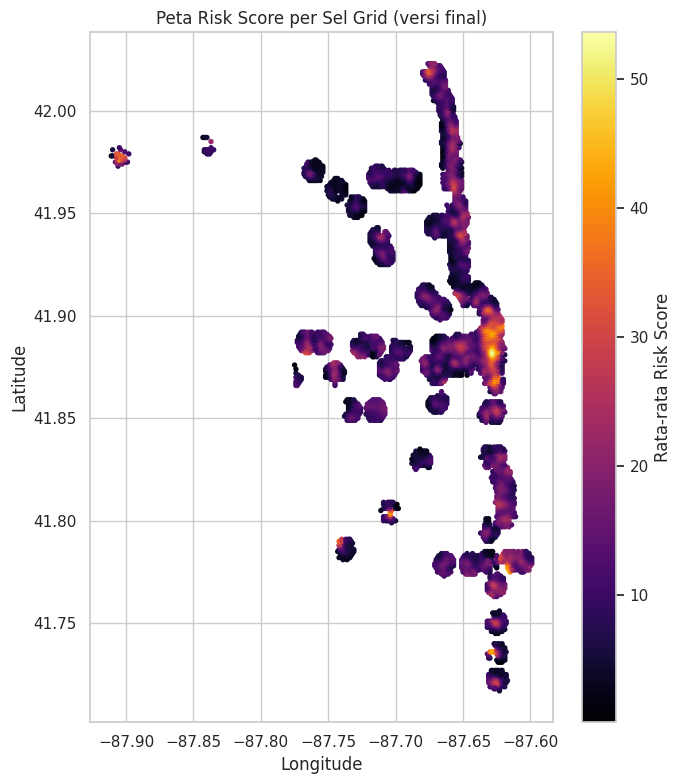

In [43]:
cell_risk = unit.groupby(["lat_r", "lon_r"], as_index=False)["risk_score"].mean()

plt.figure(figsize=(7, 8))
sc = plt.scatter(cell_risk["lon_r"], cell_risk["lat_r"], c=cell_risk["risk_score"],
                 cmap="inferno", s=8)
plt.colorbar(sc, label="Rata-rata Risk Score")
plt.title("Peta Risk Score per Sel Grid (versi final)")
plt.xlabel("Longitude"); plt.ylabel("Latitude")
plt.tight_layout(); plt.show()


# 6. Audit EDA Dataset Akhir dan Penyimpanan

Sebelum dataset disimpan, dijalankan satu rangkaian audit menyeluruh yang mencakup nilai kosong,
duplikasi, outlier, korelasi antar fitur, dan keseimbangan kelas. Audit ini sengaja ditempatkan di
akhir agar yang diperiksa adalah dataset yang benar-benar akan dipakai, bukan tabel antara yang
masih akan berubah.

Satu hal yang wajib dibaca dari matriks korelasi adalah pasangan fitur dengan korelasi sangat
tinggi. Multikolinearitas berlebihan membuat kontribusi masing-masing fitur sulit dipisahkan dan
koefisien model menjadi tidak stabil, meskipun akurasi keseluruhan bisa saja tetap terlihat baik.

**Fitur temporal `is_weekend`** ditambahkan pada tahap ini sebagai flag biner, karena EDA
menunjukkan bentuk pola jam hari kerja dan akhir pekan cukup berbeda (Bagian 3.4). Model perlu
sinyal eksplisit tersebut, karena `dow_sin` dan `dow_cos` memperlakukan seluruh hari sebagai
kontinum siklikal tanpa membedakan hari kerja dari hari libur.

**Catatan penting untuk tahap modeling.**

Sejumlah fitur bersifat konstan per sel dan terulang di seluruh 168 kombinasi hari dan jam milik
sel tersebut. Konsekuensinya, ukuran sampel efektif untuk fitur-fitur itu adalah jumlah sel, bukan
jumlah baris. Pembagian data latih dan data uji secara acak akan menempatkan sel yang sama di kedua
sisi dan membuat skor validasi menggembung tanpa dasar. Karena itu pembagian data pada Chekpoint 2
wajib dikelompokkan berdasarkan `cell_id`, misalnya dengan `GroupKFold` atau `GroupShuffleSplit`.


### Visual Risk Indicator, Tiga Tier

`risk_score` dikategorikan menjadi tiga tier, yaitu Aman, Waspada, dan Rawan.

**Kenapa bukan dibagi tiga sama rata.**

Pembagian pada persentil 33 dan 66 memang adaptif terhadap bentuk distribusi, tetapi hasil akhirnya
tetap sepertiga untuk masing-masing tier. Untuk sebuah indikator visual, proporsi seperti itu buruk
secara desain produk. Indikator merah yang menyala di sepertiga peta akan berhenti dibaca sebagai
peringatan dalam hitungan hari. Fenomena ini dikenal sebagai kelelahan peringatan, dan akibatnya
justru berbahaya, karena peringatan yang benar-benar penting ikut diabaikan.

**Ambang batas yang dipakai: persentil 65 dan 90.**

Target proporsinya kira-kira 65 persen Aman, 25 persen Waspada, dan 10 persen Rawan.

- **Rawan sekitar sepuluh persen** cukup jarang untuk tetap bermakna ketika muncul, sekaligus cukup
  sering untuk berguna. Proporsi ini sejalan dengan konvensi sistem peringatan publik pada umumnya,
  yang memang merancang level tertinggi agar jarang menyala.
- **Aman sebagai mayoritas** adalah gambaran yang akurat, bukan optimisme. Di area dalam radius 600
  meter dari stasiun transit, mayoritas kombinasi lokasi dan waktu memang relatif aman. Peta yang
  sebagian besar hijau justru mencerminkan kenyataan.

**Ambang batas dibekukan setelah dihitung.**

Nilai `T_LOW` dan `T_HIGH` disimpan sebagai konstanta, bukan dihitung ulang setiap kali data baru
masuk. Kalau ambang batas ikut bergeser mengikuti distribusi terbaru, sebuah lokasi bisa berubah
warna padahal tingkat risikonya tidak berubah sama sekali, semata karena lokasi lain membaik atau
memburuk. Untuk indikator yang dipakai berulang kali, stabilitas semacam ini penting agar warna
dapat dipercaya.

**Validasi pemisahan tier.**

Ambang batas yang baik tidak cukup dinilai dari proporsinya saja. Tiga hal ikut diperiksa:

1. Apakah sebaran nilai antar tier benar-benar terpisah, bukan garis tipis yang saling tumpang
   tindih.
2. Apakah sebuah lokasi tidak berpindah tier terlalu sering sepanjang minggu, karena indikator yang
   berkedip akan terasa tidak dapat dipercaya.
3. Apakah tier Rawan memang mengelompok pada jam-jam yang sesuai dengan temuan EDA. Kalau tier
   Rawan tersebar merata di seluruh jam, berarti komponen temporal tidak bekerja.

Nama tier ditulis sebagai teks biasa, bukan emoji, karena emoji tidak tersedia pada font default
matplotlib dan akan memunculkan peringatan glyph pada setiap grafik. Pemetaan ke warna hijau,
kuning, dan merah dilakukan di sisi aplikasi.


Ambang batas (dibekukan): T_LOW = 14.43, T_HIGH = 25.39
risk_tier
Aman       0.65
Waspada    0.25
Rawan      0.10

Sebaran risk_raw per tier:
             min    25%    50%    75%     max
risk_tier                                    
Aman       0.002  0.170  0.269  0.384   0.539
Rawan      1.131  1.307  1.593  2.174  18.604
Waspada    0.539  0.621  0.726  0.875   1.131

Jumlah tier berbeda yang dialami satu sel sepanjang minggu:
risk_tier
1    1041
2    1855
3    3589


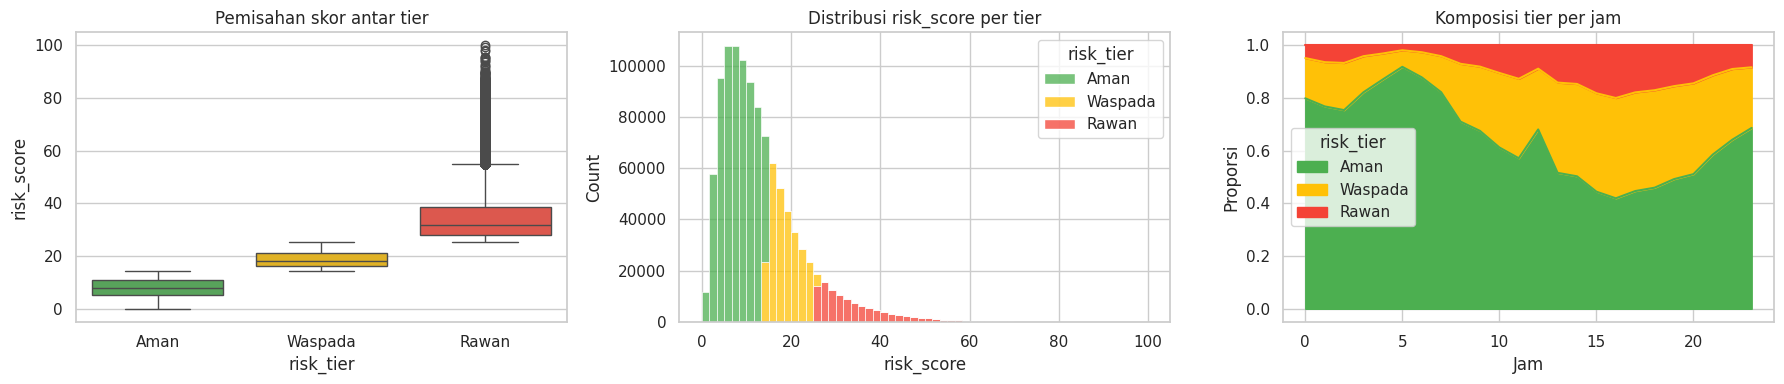

In [44]:
# ================= Penetapan Tier =================
signal = unit.loc[unit["risk_raw"] > 0, "risk_score"]
T_LOW  = float(signal.quantile(0.65))
T_HIGH = float(signal.quantile(0.90))

unit["risk_tier"] = np.select(
    [unit["risk_score"] <= T_LOW, unit["risk_score"] <= T_HIGH],
    ["Aman", "Waspada"],
    default="Rawan",
)

print(f"Ambang batas (dibekukan): T_LOW = {T_LOW:.2f}, T_HIGH = {T_HIGH:.2f}")
print(unit["risk_tier"].value_counts(normalize=True).round(3).to_string())

# --- Validasi 1: apakah tier benar-benar terpisah
print("\nSebaran risk_raw per tier:")
print(unit.groupby("risk_tier")["risk_raw"]
          .describe()[["min", "25%", "50%", "75%", "max"]].round(3).to_string())

# --- Validasi 2: stabilitas, apakah satu sel berkedip antar tier sepanjang minggu
flip = unit.groupby("cell_id")["risk_tier"].nunique()
print("\nJumlah tier berbeda yang dialami satu sel sepanjang minggu:")
print(flip.value_counts().sort_index().to_string())

# --- Validasi 3: apakah tier Rawan mengelompok di jam yang masuk akal
TIER_ORDER  = ["Aman", "Waspada", "Rawan"]
TIER_COLORS = {"Aman": "#4CAF50", "Waspada": "#FFC107", "Rawan": "#F44336"}

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

sns.boxplot(data=unit, x="risk_tier", y="risk_score", ax=axes[0], order=TIER_ORDER,
            hue="risk_tier", palette=TIER_COLORS, legend=False)
axes[0].set_title("Pemisahan skor antar tier")

sns.histplot(data=unit, x="risk_score", hue="risk_tier", bins=60, multiple="stack",
             palette=TIER_COLORS, hue_order=TIER_ORDER, ax=axes[1])
axes[1].set_title("Distribusi risk_score per tier")

(pd.crosstab(unit["hour"], unit["risk_tier"], normalize="index")
   .reindex(columns=TIER_ORDER, fill_value=0)
   .plot(kind="area", stacked=True, ax=axes[2],
         color=[TIER_COLORS[t] for t in TIER_ORDER]))
axes[2].set_title("Komposisi tier per jam")
axes[2].set_xlabel("Jam"); axes[2].set_ylabel("Proporsi")

plt.tight_layout(); plt.show()


Shape dataset akhir: (1089480, 24)

=== 1. Missing value ===
Tidak ada nilai kosong

=== 2. Duplikasi ===
Baris identik penuh : 0
Duplikat kunci unit : 0 (harus 0)

=== 3. Outlier dan skewness ===
  hist_crime_count               outlier  101,136 ( 9.28%)  skew  10.03
  crime_diversity                outlier      504 ( 0.05%)  skew   0.69
  violent_share                  outlier        0 ( 0.00%)  skew   0.82
  night_share                    outlier   40,320 ( 3.70%)  skew   1.37
  seasonal_cv                    outlier        0 ( 0.00%)  skew   0.83
  dist_to_nearest_safe_place     outlier        0 ( 0.00%)  skew   0.30
  n_safe_places_within_radius    outlier   73,248 ( 6.72%)  skew   2.43
  risk_score                     outlier   46,903 ( 4.31%)  skew   1.76


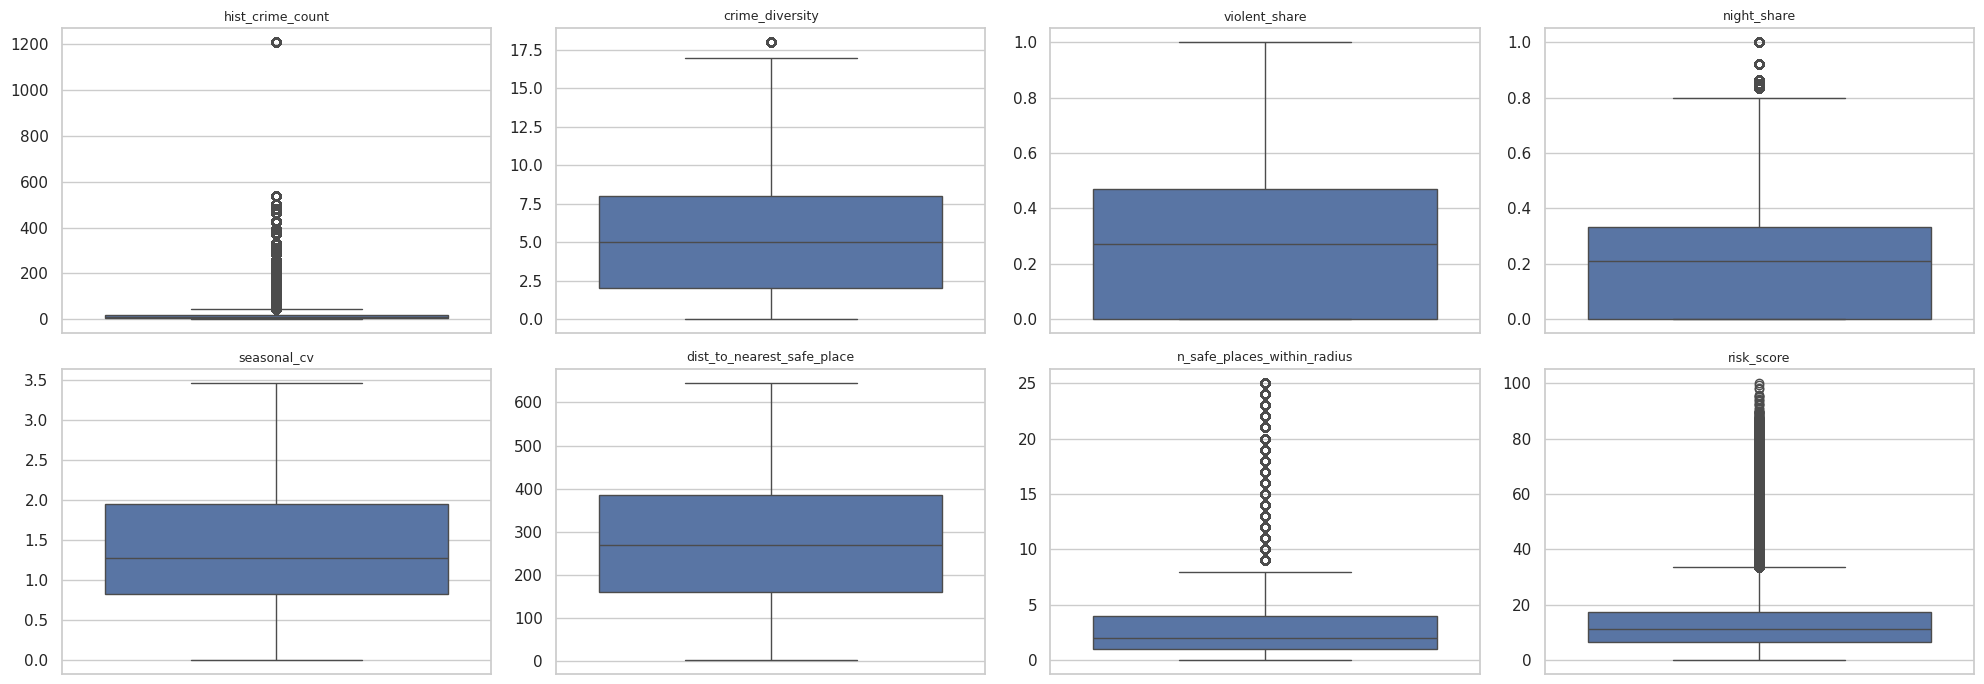


=== 4. Korelasi dan multikolinearitas ===


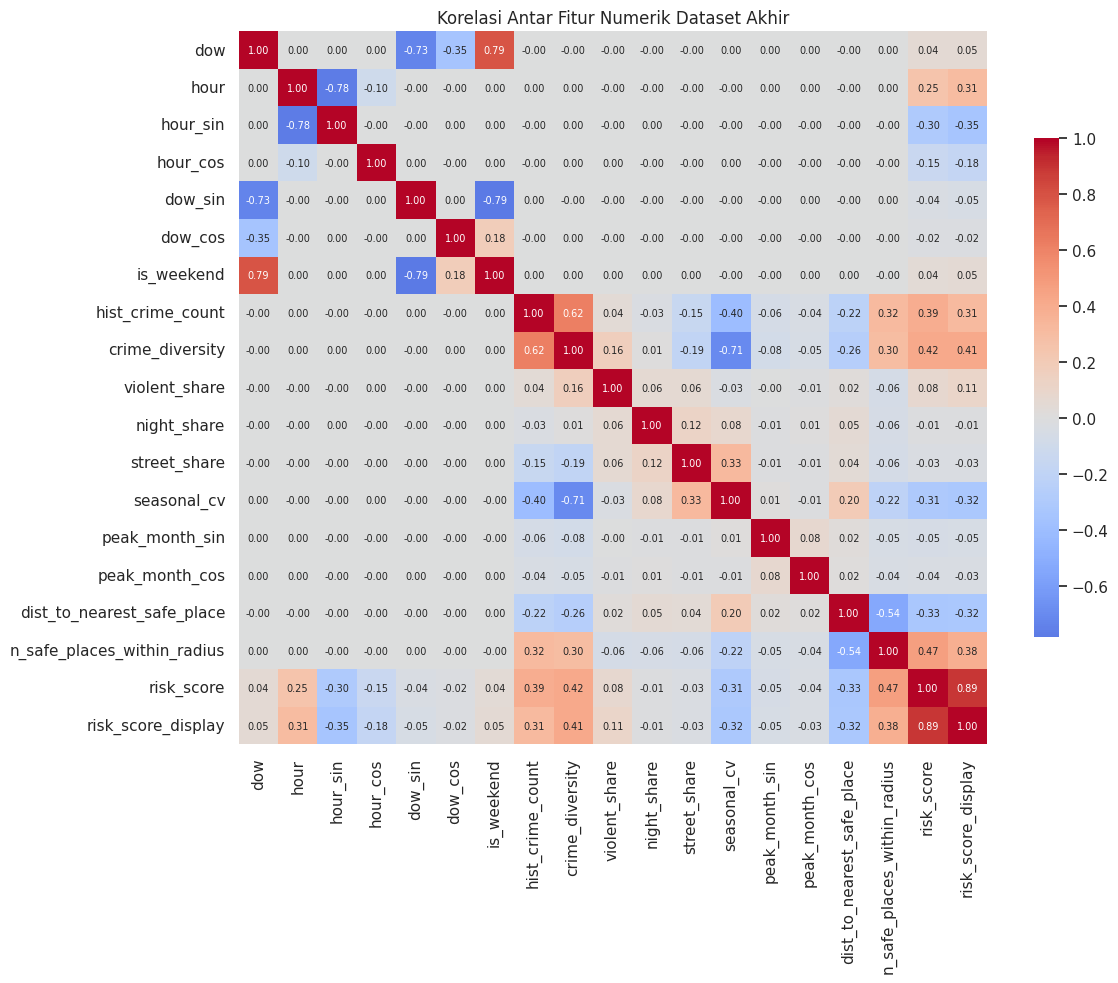

Pasangan dengan |r| > 0.8:
risk_score  risk_score_display    0.89

=== 5. Keseimbangan kelas ===
risk_tier
Aman       0.65
Waspada    0.25
Rawan      0.10

Jenis kejahatan dominan per sel (10 teratas):
dominant_crime_type
THEFT                  0.342
BATTERY                0.213
CRIMINAL DAMAGE        0.110
MOTOR VEHICLE THEFT    0.078
ASSAULT                0.067
DECEPTIVE PRACTICE     0.034
OTHER OFFENSE          0.032
BURGLARY               0.028
NONE                   0.023
NARCOTICS              0.021


In [45]:
# ================= Audit EDA Dataset Akhir =================
unit["hour_sin"], unit["hour_cos"] = cyclical_encode(unit["hour"], 24)
unit["dow_sin"],  unit["dow_cos"]  = cyclical_encode(unit["dow"], 7)
unit["is_weekend"] = unit["dow"].isin([5, 6]).astype(int)

unit = unit.merge(
    cell_centroids[["cell_id", "dist_to_nearest_safe_place", "n_safe_places_within_radius"]],
    on="cell_id", how="left")

FINAL_COLS = [
    "cell_id", "lat_r", "lon_r",
    "dow", "hour", "hour_sin", "hour_cos", "dow_sin", "dow_cos", "is_weekend",
    "hist_crime_count", "crime_diversity", "violent_share", "night_share", "street_share",
    "seasonal_cv", "peak_month_sin", "peak_month_cos", "dominant_crime_type",
    "dist_to_nearest_safe_place", "n_safe_places_within_radius",
    "risk_score", "risk_score_display", "risk_tier",
]
final = unit[FINAL_COLS].copy()
print(f"Shape dataset akhir: {final.shape}\n")

print("=== 1. Missing value ===")
m = final.isna().sum()
print(m[m > 0].to_string() if m.sum() else "Tidak ada nilai kosong")

print("\n=== 2. Duplikasi ===")
print(f"Baris identik penuh : {final.duplicated().sum():,}")
print(f"Duplikat kunci unit : "
      f"{final.duplicated(subset=['cell_id', 'dow', 'hour']).sum():,} (harus 0)")

print("\n=== 3. Outlier dan skewness ===")
num_cols = ["hist_crime_count", "crime_diversity", "violent_share", "night_share",
            "seasonal_cv", "dist_to_nearest_safe_place", "n_safe_places_within_radius",
            "risk_score"]
for c in num_cols:
    q1, q3 = final[c].quantile([.25, .75]); iqr = q3 - q1
    n_out = ((final[c] < q1 - 1.5 * iqr) | (final[c] > q3 + 1.5 * iqr)).sum()
    print(f"  {c:30s} outlier {n_out:>8,} ({n_out / len(final) * 100:5.2f}%)  "
          f"skew {final[c].skew():>6.2f}")

fig, axes = plt.subplots(2, 4, figsize=(20, 7))
for ax, c in zip(axes.ravel(), num_cols):
    sns.boxplot(y=final[c], ax=ax, color="#4C72B0")
    ax.set_title(c, fontsize=9); ax.set_ylabel("")
plt.tight_layout(); plt.show()

print("\n=== 4. Korelasi dan multikolinearitas ===")
corr = final.select_dtypes("number").drop(columns=["lat_r", "lon_r"]).corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            annot_kws={"size": 7}, cbar_kws={"shrink": .7})
plt.title("Korelasi Antar Fitur Numerik Dataset Akhir")
plt.tight_layout(); plt.show()

pairs = (corr.abs().where(np.triu(np.ones(corr.shape), k=1).astype(bool))
             .stack().sort_values(ascending=False))
print("Pasangan dengan |r| > 0.8:")
print(pairs[pairs > 0.8].round(3).to_string() if (pairs > 0.8).any()
      else "  Tidak ada, multikolinearitas berlebihan tidak terdeteksi")

print("\n=== 5. Keseimbangan kelas ===")
print(final["risk_tier"].value_counts(normalize=True).round(3).to_string())
print("\nJenis kejahatan dominan per sel (10 teratas):")
print(final.drop_duplicates("cell_id")["dominant_crime_type"]
        .value_counts(normalize=True).head(10).round(3).to_string())


In [46]:
# ================= Validasi Akhir dan Penyimpanan =================
checks = {
    "Grid unit lengkap":
        len(final) == n_cells * N_SLOTS,
    "Tersedia unit tanpa kejadian (contoh negatif ada)":
        (unit["obs_count"] == 0).sum() > 0,
    "Tidak ada nilai kosong":
        final.isna().sum().sum() == 0,
    "Tidak ada duplikat kunci unit":
        final.duplicated(subset=["cell_id", "dow", "hour"]).sum() == 0,
    "Tidak ada kolom pembentuk label yang bocor sebagai fitur":
        not any(c in final.columns for c in
                ["obs_count", "obs_value", "base_value", "risk_raw",
                 "crime_count", "cell_total", "cell_n", "alpha", "global_share"]),
    "risk_score berada pada rentang 0 sampai 100":
        final["risk_score"].between(0, 100).all(),
    "Ketiga tier terisi":
        final["risk_tier"].nunique() == 3,
    "Koordinat berada di dalam bounding box Chicago":
        final["lat_r"].between(41.60, 42.05).all()
        and final["lon_r"].between(-87.95, -87.50).all(),
}
for name, ok in checks.items():
    print(f"  [{'OK   ' if ok else 'GAGAL'}] {name}")
assert all(checks.values()), "Ada validasi yang gagal, periksa sebelum menyimpan"

final.to_csv(DATA_DIR / "features_labels.csv", index=False)
print(f"\nTersimpan: {DATA_DIR / 'features_labels.csv'}  ({final.shape[0]:,} baris x {final.shape[1]} kolom)")
try:
    final.to_parquet(DATA_DIR / "features_labels.parquet", index=False)
    print(f"Tersimpan: {DATA_DIR / 'features_labels.parquet'}")
except Exception:
    print("Parquet dilewati, CSV sudah cukup")

# Konstanta ambang batas ikut disimpan agar tier dapat direproduksi pada data baru
pd.DataFrame([{
    "T_LOW": T_LOW, "T_HIGH": T_HIGH,
    "half_life_days": HALF_LIFE_DAYS, "label_window_days": LABEL_WINDOW_DAYS,
    "cutoff": str(CUTOFF), "reference_date": str(REFERENCE_DATE),
    "radius_km": RADIUS_KM, "sigma_km": SIGMA_KM, "k_shrink": K_SHRINK,
    "grid_decimals": ROUND_DECIMALS, "station_radius_m": RADIUS_M,
    "safe_place_radius_m": SAFE_PLACE_RADIUS_M,
}]).to_csv(DATA_DIR / "model_config.csv", index=False)
print(f"Tersimpan: {DATA_DIR / 'model_config.csv'}")

final.head()


  [OK   ] Grid unit lengkap
  [OK   ] Tersedia unit tanpa kejadian (contoh negatif ada)
  [OK   ] Tidak ada nilai kosong
  [OK   ] Tidak ada duplikat kunci unit
  [OK   ] Tidak ada kolom pembentuk label yang bocor sebagai fitur
  [OK   ] risk_score berada pada rentang 0 sampai 100
  [OK   ] Ketiga tier terisi
  [OK   ] Koordinat berada di dalam bounding box Chicago

Tersimpan: data/features_labels.csv  (1,089,480 baris x 24 kolom)
Tersimpan: data/features_labels.parquet
Tersimpan: data/model_config.csv


,cell_id,lat_r,lon_r,dow,hour,hour_sin,hour_cos,dow_sin,dow_cos,is_weekend,hist_crime_count,crime_diversity,violent_share,night_share,street_share,seasonal_cv,peak_month_sin,peak_month_cos,dominant_crime_type,dist_to_nearest_safe_place,n_safe_places_within_radius,risk_score,risk_score_display,risk_tier
0,41.717_-87.623,41.717,-87.623,0,0,0.000000,1.000000,0.0,1.0,0,4.0,4.0,0.0,0.5,0.75,1.477098,0.866025,0.5,OTHER OFFENSE,608.18131,0,3.717163,8.157102,Aman
1,41.717_-87.623,41.717,-87.623,0,1,0.258819,0.965926,0.0,1.0,0,4.0,4.0,0.0,0.5,0.75,1.477098,0.866025,0.5,OTHER OFFENSE,608.18131,0,2.806596,4.265797,Aman
2,41.717_-87.623,41.717,-87.623,0,2,0.500000,0.866025,0.0,1.0,0,4.0,4.0,0.0,0.5,0.75,1.477098,0.866025,0.5,OTHER OFFENSE,608.18131,0,3.130939,5.536403,Aman
3,41.717_-87.623,41.717,-87.623,0,3,0.707107,0.707107,0.0,1.0,0,4.0,4.0,0.0,0.5,0.75,1.477098,0.866025,0.5,OTHER OFFENSE,608.18131,0,2.936662,4.760712,Aman
4,41.717_-87.623,41.717,-87.623,0,4,0.866025,0.500000,0.0,1.0,0,4.0,4.0,0.0,0.5,0.75,1.477098,0.866025,0.5,OTHER OFFENSE,608.18131,0,1.881183,1.520725,Aman


# 7. Ringkasan Pipeline

Alur akhir yang dijalankan notebook ini:

| Tahap | Keluaran | Bagian |
| :-- | :-- | :-- |
| Audit dan pembersihan | Data bebas duplikat, koordinat valid, artefak waktu dibuang | 2.0 sampai 3.7 |
| Subset spasial | Kejadian dalam radius jalan kaki dari stasiun | 2.1 |
| Feature engineering | Grid sel, encoding siklikal, fitur safe place | 4.1 sampai 4.2c |
| Severity scoring | `severity_v2`, dua level dengan modifier terverifikasi | 5.1 |
| Pemisahan jendela | `df_hist` untuk fitur, `df_label` untuk target | 5.2 |
| Unit analisis | Grid penuh sel kali hari kali jam, penyusutan empiris | 5.2b |
| Fitur prediktor | Tujuh fitur historis di level sel | 5.2c |
| Penghalusan spasial | `risk_raw`, kernel Gaussian dengan radius terpilih | 5.3 |
| Normalisasi | `risk_score` dan `risk_score_display` | 5.4 |
| Kategorisasi | `risk_tier` dengan ambang batas yang dibekukan | 6 |
| Audit dan ekspor | Empat berkas keluaran | 6 dan 6.1 |


# 8. Snapshot Periodik untuk Continual Learning (Persiapan HO2)

Seluruh pipeline di atas menghasilkan satu snapshot risk_score, yaitu potret kondisi
"sekarang" berdasarkan 180 hari terakhir. Snapshot tunggal ini cukup untuk melatih
model utama, tapi tidak bisa dipakai untuk mensimulasikan kedatangan data bertahap di
HO2, karena tidak ada sumbu waktu kalender yang tersisa di baris unitnya.

Section ini menambahkan artefak kedua, yaitu rangkaian snapshot berurutan waktu. Alur
severity, temporal decay, grid penuh, penyusutan empiris, spatial smoothing, dan
normalisasi tetap dipakai persis sama seperti di atas, hanya saja dijalankan berulang
untuk beberapa periode waktu yang berurutan, bukan sekali untuk seluruh data.

Setiap periode diberi kolom `period` yang menandai urutan kronologis aslinya. Kolom
inilah yang nanti dipakai HO2 untuk membentuk batch data secara kronologis, bukan
dengan pengacakan seperti sebelumnya.

In [47]:
# ================= Definisi Periode Kronologis =================
PERIOD_LENGTH_DAYS   = 30   # tiap periode merepresentasikan sekitar satu bulan data baru
N_PERIODS            = 6    # disamakan dengan jumlah batch yang dipakai di HO2
MIN_HIST_DAYS        = 365  # periode pertama baru dimulai setelah histori cukup panjang tersedia
HALF_LIFE_DAYS_PERIOD = 15  # setengah dari panjang periode, konsisten dengan filosofi HALF_LIFE_DAYS di atas

data_start = df["Datetime"].min()
data_end   = df["Datetime"].max()

first_period_end = data_start + pd.Timedelta(days=MIN_HIST_DAYS + PERIOD_LENGTH_DAYS)
period_ends = [first_period_end + pd.Timedelta(days=PERIOD_LENGTH_DAYS * i)
               for i in range(N_PERIODS)]
period_ends = [p for p in period_ends if p <= data_end]

print(f"Jumlah periode yang bisa dibentuk: {len(period_ends)}")
for i, p in enumerate(period_ends):
    print(f"  Periode {i}: berakhir di {p.date()}")

Jumlah periode yang bisa dibentuk: 6
  Periode 0: berakhir di 2025-01-30
  Periode 1: berakhir di 2025-03-01
  Periode 2: berakhir di 2025-03-31
  Periode 3: berakhir di 2025-04-30
  Periode 4: berakhir di 2025-05-30
  Periode 5: berakhir di 2025-06-29


### 8.1 Fungsi Pembangun Satu Snapshot Periode

Fungsi berikut mengulang persis logika yang sama dengan Bagian 5.2b, 5.2c, dan 5.3,
hanya saja diparameterisasi oleh titik akhir periode. Dua hal dijaga konsisten dengan
prinsip yang sudah dipakai di seluruh pipeline ini.

Pertama, jendela historis untuk sebuah periode hanya berisi kejadian sebelum periode
itu dimulai, bukan seluruh histori tiga tahun. Ini meniru kondisi dunia nyata, yaitu
semakin ke belakang periodenya, semakin sedikit histori yang tersedia untuk model,
persis seperti continual learning yang sesungguhnya.

Kedua, matriks bobot tetangga spasial (`W`) tidak dihitung ulang tiap periode, karena
koordinat sel tidak berubah antar waktu. Yang berubah hanya `base_value` di tiap sel.
Ini menghemat komputasi secara signifikan dibanding membangun ulang BallTree setiap
periode.

In [48]:
def build_period_snapshot(period_end, period_index):
    """Membangun satu snapshot unit (cell_id x dow x hour) untuk satu periode waktu.
    Mengulang logika Bagian 5.2b, 5.2c, dan 5.3, diparameterisasi oleh period_end."""

    period_start = period_end - pd.Timedelta(days=PERIOD_LENGTH_DAYS)

    # --- Pemisahan histori vs label, relatif terhadap periode ini ---
    df_hist_p  = df[df["Datetime"] <  period_start].copy()
    df_label_p = df[(df["Datetime"] >= period_start) & (df["Datetime"] < period_end)].copy()

    df_label_p["age_days"]    = (period_end - df_label_p["Datetime"]).dt.total_seconds() / 86400
    df_label_p["w_time"]      = 0.5 ** (df_label_p["age_days"] / HALF_LIFE_DAYS_PERIOD)
    df_label_p["event_value"] = df_label_p["severity_v2"] * df_label_p["w_time"]

    # --- Grid penuh + penyusutan empiris (meniru logika di Bagian 5.2b) ---
    obs_p = (df_label_p.groupby(["cell_id", "dow", "hour"], as_index=False)
             .agg(obs_value=("event_value", "sum"), obs_count=("ID", "size")))

    unit_p = full_grid.merge(obs_p, on=["cell_id", "dow", "hour"], how="left")
    unit_p[["obs_value", "obs_count"]] = unit_p[["obs_value", "obs_count"]].fillna(0)
    unit_p = unit_p.merge(coords_lookup, on="cell_id", how="left")

    cell_total_p = df_label_p.groupby("cell_id")["event_value"].sum()
    cell_n_p     = df_label_p.groupby("cell_id")["ID"].size()
    unit_p["cell_total"] = unit_p["cell_id"].map(cell_total_p).fillna(0.0)
    unit_p["cell_n"]     = unit_p["cell_id"].map(cell_n_p).fillna(0).astype(int)

    total_value_p = df_label_p["event_value"].sum()
    if total_value_p > 0:
        global_share_p = (df_label_p.groupby(["dow", "hour"])["event_value"].sum()
                           / total_value_p).rename("global_share").reset_index()
        unit_p = unit_p.merge(global_share_p, on=["dow", "hour"], how="left")
    else:
        unit_p["global_share"] = np.nan
    unit_p["global_share"] = unit_p["global_share"].fillna(1 / N_SLOTS)

    K_SHRINK_PERIOD = K_SHRINK * (PERIOD_LENGTH_DAYS / LABEL_WINDOW_DAYS)
    unit_p["alpha"] = unit_p["cell_n"] / (unit_p["cell_n"] + K_SHRINK_PERIOD)
    unit_p["base_value"] = (unit_p["alpha"] * unit_p["obs_value"]
                            + (1 - unit_p["alpha"]) * unit_p["cell_total"] * unit_p["global_share"])

    # --- Fitur historis dari df_hist_p (meniru logika di Bagian 5.2c) ---
    df_hist_p["is_violent"] = df_hist_p["Primary Type"].str.upper().isin(VIOLENT_TYPES)
    df_hist_p["is_night"]   = df_hist_p["hour"].isin([22, 23, 0, 1, 2, 3, 4])
    df_hist_p["is_street"]  = (df_hist_p["Location Description"].fillna("")
                               .str.upper().str.contains("|".join(PUBLIC_SPACE)))

    cell_feat_p = (df_hist_p.groupby("cell_id").agg(
        hist_crime_count = ("ID", "size"),
        crime_diversity  = ("Primary Type", "nunique"),
        violent_share    = ("is_violent", "mean"),
        night_share      = ("is_night", "mean"),
        street_share     = ("is_street", "mean"),
    ).reset_index())

    dominant_p = (df_hist_p.groupby(["cell_id", "Primary Type"]).size()
              .reset_index(name="n")
              .sort_values("n", ascending=False)
              .drop_duplicates("cell_id")[["cell_id", "Primary Type"]]
              .rename(columns={"Primary Type": "dominant_crime_type"}))

    years_per_month_p = df_hist_p.groupby("month")["Year"].nunique()
    monthly_p      = df_hist_p.groupby(["cell_id", "month"]).size().unstack(fill_value=0)
    monthly_norm_p = monthly_p.div(years_per_month_p.reindex(monthly_p.columns).values, axis=1)

    seasonal_p = pd.DataFrame({
        "cell_id": monthly_norm_p.index,
        "seasonal_cv": (monthly_norm_p.std(axis=1)
                        / monthly_norm_p.mean(axis=1).replace(0, np.nan)).fillna(0).values,
        "peak_month": monthly_norm_p.idxmax(axis=1).values,
    })
    seasonal_p["peak_month_sin"], seasonal_p["peak_month_cos"] = cyclical_encode(
        seasonal_p["peak_month"], 12)

    cell_feat_p = (cell_feat_p
                  .merge(dominant_p, on="cell_id", how="left")
                  .merge(seasonal_p.drop(columns="peak_month"), on="cell_id", how="left"))

    unit_p = unit_p.merge(cell_feat_p, on="cell_id", how="left")

    hist_cols = ["hist_crime_count", "crime_diversity", "violent_share", "night_share",
             "street_share", "seasonal_cv", "peak_month_sin", "peak_month_cos"]
    unit_p[hist_cols] = unit_p[hist_cols].fillna(0)
    unit_p["dominant_crime_type"] = unit_p["dominant_crime_type"].fillna("NONE")

    # --- Spatial smoothing, pakai ulang W yang sudah dibangun di Bagian 5.3 ---
    unit_p["cell_idx"] = unit_p["cell_id"].map(cell_to_idx)
    unit_p = unit_p.sort_values(["cell_idx", "dow", "hour"]).reset_index(drop=True)
    V_p = unit_p["base_value"].values.reshape(n_cells, N_SLOTS)
    denom = np.asarray(W.sum(axis=1)).ravel()
    S_p = W.dot(V_p) / denom[:, None]
    unit_p["risk_raw"] = S_p.reshape(-1)

    unit_p["period"]       = period_index
    unit_p["period_end"]   = period_end
    unit_p["hour_sin"], unit_p["hour_cos"] = cyclical_encode(unit_p["hour"], 24)
    unit_p["dow_sin"],  unit_p["dow_cos"]  = cyclical_encode(unit_p["dow"], 7)
    unit_p["is_weekend"]   = unit_p["dow"].isin([5, 6]).astype(int)

    return unit_p

### 8.2 Normalisasi Dibekukan dari Periode Pertama

Kalau `risk_raw` dinormalisasi ulang secara independen di tiap periode, perubahan asli
antar waktu akan hilang, karena tiap periode selalu direntangkan ulang ke rentang 0
sampai 100 relatif terhadap dirinya sendiri. Padahal tujuan snapshot ini justru untuk
menunjukkan perubahan itu.

Solusinya, parameter normalisasi (`log1p` lalu min-max) dihitung sekali dari periode
pertama saja, lalu dibekukan dan dipakai konsisten ke seluruh periode berikutnya. Ini
prinsip yang sama dengan target encoding di HO2, yaitu statistik dihitung dari data
acuan, dibekukan, lalu diterapkan ke data lain tanpa dihitung ulang.

In [49]:
# ================= Bangun Seluruh Snapshot Periode =================
period_snapshots = []
for i, p_end in enumerate(period_ends):
    snap = build_period_snapshot(p_end, i)
    period_snapshots.append(snap)
    print(f"Periode {i} ({p_end.date()}) selesai, {len(snap):,} baris, "
          f"risk_raw range {snap['risk_raw'].min():.4f} .. {snap['risk_raw'].max():.4f}")

# --- Bekukan parameter normalisasi dari periode pertama (index 0) ---
ref_rr = period_snapshots[0]["risk_raw"]
ref_shift = -ref_rr.min()                     # supaya log1p(rr + shift) selalu >= 0
ref_log = np.log1p(ref_rr + ref_shift)
LOG_MIN, LOG_MAX = ref_log.min(), ref_log.max()

print(f"\nParameter normalisasi dibekukan dari periode 0: "
      f"shift={ref_shift:.4f}, log_min={LOG_MIN:.4f}, log_max={LOG_MAX:.4f}")

for snap in period_snapshots:
    rr_log = np.log1p(snap["risk_raw"] + ref_shift)
    snap["risk_score"] = 100 * (rr_log - LOG_MIN) / (LOG_MAX - LOG_MIN)
    snap["risk_score"] = snap["risk_score"].clip(0, 100)  # jaga-jaga kalau periode lebih ekstrem dari acuan

timeseries_final = pd.concat(period_snapshots, ignore_index=True)
print(f"\nShape gabungan seluruh periode: {timeseries_final.shape}")

Periode 0 (2025-01-30) selesai, 1,089,480 baris, risk_raw range 0.0000 .. 10.0684
Periode 1 (2025-03-01) selesai, 1,089,480 baris, risk_raw range 0.0000 .. 14.6176
Periode 2 (2025-03-31) selesai, 1,089,480 baris, risk_raw range 0.0000 .. 9.8467
Periode 3 (2025-04-30) selesai, 1,089,480 baris, risk_raw range 0.0000 .. 13.0533
Periode 4 (2025-05-30) selesai, 1,089,480 baris, risk_raw range 0.0000 .. 12.7549
Periode 5 (2025-06-29) selesai, 1,089,480 baris, risk_raw range 0.0000 .. 11.2754

Parameter normalisasi dibekukan dari periode 0: shift=-0.0000, log_min=0.0000, log_max=2.4041

Shape gabungan seluruh periode: (6536880, 31)


In [50]:
from scipy.stats import skew

print("Skewness risk_score (timeseries):", skew(timeseries_final["risk_score"]))
print("Proporsi risk_score == 0:", (timeseries_final["risk_score"] == 0).mean())
print("Proporsi risk_score >= 90:", (timeseries_final["risk_score"] >= 90).mean())

print("\nDistribusi risk_score setelah perbaikan K_SHRINK dan fitur musiman:")
print(timeseries_final["risk_score"].describe())
print("\nStandar deviasi risk_score per periode (harusnya tidak mendekati nol):")
print(timeseries_final.groupby("period")["risk_score"].std())

print("\nDistribusi crime_diversity:")
print(timeseries_final["crime_diversity"].describe())
print("\nRata-rata crime_diversity per periode:")
print(timeseries_final.groupby("period")["crime_diversity"].mean())

print("\nDistribusi seasonal_cv:")
print(timeseries_final["seasonal_cv"].describe())
print("\nProporsi seasonal_cv == 0:", (timeseries_final["seasonal_cv"] == 0).mean())

Skewness risk_score (timeseries): 4.533400833403449
Proporsi risk_score == 0: 0.0026985350809560524
Proporsi risk_score >= 90: 6.578061705278359e-06

Distribusi risk_score setelah perbaikan K_SHRINK dan fitur musiman:
count    6.536880e+06
mean     3.612754e+00
std      4.779503e+00
min      0.000000e+00
25%      1.134723e+00
50%      2.268308e+00
75%      4.198990e+00
max      1.000000e+02
Name: risk_score, dtype: float64

Standar deviasi risk_score per periode (harusnya tidak mendekati nol):
period
0    4.360591
1    4.616658
2    4.679206
3    4.795919
4    4.862671
5    5.272627
Name: risk_score, dtype: float64

Distribusi crime_diversity:
count    6.536880e+06
mean     4.277358e+00
std      3.258529e+00
min      0.000000e+00
25%      2.000000e+00
50%      4.000000e+00
75%      6.000000e+00
max      1.700000e+01
Name: crime_diversity, dtype: float64

Rata-rata crime_diversity per periode:
period
0    3.918736
1    4.067386
2    4.203547
3    4.348497
4    4.491904
5    4.634079
Nam

### 8.3 Kenapa Distribusi risk_score Menjadi Lebih Skewed Setelah Perbaikan

Setelah `K_SHRINK` diskalakan ulang mengikuti panjang tiap periode (Bagian 8.1), skewness
`risk_score` pada dataset time series ini naik menjadi 4,53, jauh lebih tinggi dibanding
1,76 pada dataset utama. Angka ini bukan tanda kemunduran, melainkan konsekuensi langsung
dari perbaikan itu sendiri, dan perlu dijelaskan agar tidak disalahartikan sebagai bug baru.

Sebelum diperbaiki, `K_SHRINK` yang masih memakai nilai kalibrasi jendela 180 hari terlalu
besar untuk jendela 30 hari. Akibatnya hampir seluruh sel, baik yang sebenarnya sangat aman
maupun yang berisiko tinggi, ditarik mendekati rata-rata global. Distribusi yang tampak
rendah skewness-nya pada tahap itu sebetulnya adalah artefak dari shrinkage yang terlalu
berat, bukan cerminan sinyal risiko yang sesungguhnya.

Setelah `K_SHRINK` diskalakan proporsional, sel-sel sepi diperbolehkan bernilai mendekati
nol, dan sel-sel hotspot diperbolehkan menonjol sesuai kejadian yang benar-benar terjadi.
Kejahatan memang secara alami terkonsentrasi secara spasial, sebagian kecil lokasi
menyumbang sebagian besar kejadian, sehingga begitu shrinkage tidak lagi menutupinya,
distribusi yang miring tajam ke kanan ini justru lebih mencerminkan kondisi sebenarnya.

Dua implikasi yang perlu dicatat sebagai keterbatasan, bukan sebagai kegagalan.

Pertama, skala 0 sampai 100 menjadi jarang terpakai penuh, karena parameter normalisasi
dibekukan dari periode pertama yang kebetulan memiliki risk_raw maksimum paling kecil
dibanding periode-periode sesudahnya. Nilai pada periode belakangan yang lebih ekstrem
sebagian terpotong ke batas atas skala periode acuan.

Kedua, ambang batas tier (`T_LOW`, `T_HIGH`) yang dibekukan dari dataset utama tidak dapat
dipinjam langsung untuk dataset time series ini, karena konteks normalisasinya berbeda.
Ambang batas tier untuk data periodik ini perlu dihitung ulang secara khusus dari
distribusinya sendiri, idealnya berbasis kuantil karena bentuknya yang skewed.

In [51]:
# ================= Validasi dan Penyimpanan Dataset Time Series =================
checks_ts = {
    "Setiap periode punya jumlah baris sama (grid penuh)":
        timeseries_final.groupby("period").size().nunique() == 1,
    "Kolom period terisi berurutan":
        list(timeseries_final["period"].unique()) == list(range(len(period_ends))),
    "risk_score berada pada rentang 0 sampai 100":
        timeseries_final["risk_score"].between(0, 100).all(),
    "Tidak ada nilai kosong pada kolom fitur utama":
        timeseries_final[["risk_score", "hist_crime_count", "crime_diversity"]].isna().sum().sum() == 0,
}
for name, ok in checks_ts.items():
    print(f"  [{'OK   ' if ok else 'GAGAL'}] {name}")
assert all(checks_ts.values()), "Ada validasi yang gagal pada dataset time series"

TS_COLS = [
    "cell_id", "lat_r", "lon_r", "period", "period_end",
    "dow", "hour", "hour_sin", "hour_cos", "dow_sin", "dow_cos", "is_weekend",
    "hist_crime_count", "crime_diversity", "violent_share", "night_share", "street_share",
    "seasonal_cv", "peak_month_sin", "peak_month_cos", "dominant_crime_type",
    "risk_score",
]
timeseries_final[TS_COLS].to_csv(DATA_DIR / "features_labels_timeseries.csv", index=False)
print(f"\nTersimpan: {DATA_DIR / 'features_labels_timeseries.csv'}, siap dipakai HO2 untuk batching kronologis")

  [OK   ] Setiap periode punya jumlah baris sama (grid penuh)
  [OK   ] Kolom period terisi berurutan
  [OK   ] risk_score berada pada rentang 0 sampai 100
  [OK   ] Tidak ada nilai kosong pada kolom fitur utama

Tersimpan: data/features_labels_timeseries.csv, siap dipakai HO2 untuk batching kronologis
